In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import warnings
from scipy import signal
from scipy.signal import detrend
from scipy.stats import t
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import xarray as xr
import os
from glob import glob
import geopandas as gpd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
warnings.filterwarnings('ignore')

In [2]:
import xarray as xr
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# ============================
# 1️⃣ 读取海冰数据
# ============================
sic_file = "/Volumes/limenghan/气候变率/HadISST_ice.nc"
print("Loading SIC dataset...")
sic = xr.open_dataset(sic_file)['sic']

# 坐标标准化
def standardize_coords(da):
    coords = list(da.coords)
    if 'latitude' not in coords:
        lat_name = next(k for k in coords if 'lat' in k)
        da = da.rename({lat_name: 'latitude'})
    if 'longitude' not in coords:
        lon_name = next(k for k in coords if 'lon' in k)
        da = da.rename({lon_name: 'longitude'})
    return da

sic = standardize_coords(sic)

# 重采样到月起点
sic_ms = sic.resample(time='MS').mean(dim='time', skipna=True)
time_idx = pd.to_datetime(sic_ms.time.values)

# ============================
# 2️⃣ 区域选择与加权平均
# ============================
def select_region(da, lat1, lat2, lon1, lon2):
    # 纬度 slice
    if da.latitude[0] > da.latitude[-1]:
        lat_slice = slice(max(lat1, lat2), min(lat1, lat2))
    else:
        lat_slice = slice(min(lat1, lat2), max(lat1, lat2))
    
    # 经度 wrap-around
    if lon1 <= lon2:
        da_sel = da.sel(latitude=lat_slice, longitude=slice(lon1, lon2))
    else:
        da1 = da.sel(latitude=lat_slice, longitude=slice(lon1, da.longitude.max().item()))
        da2 = da.sel(latitude=lat_slice, longitude=slice(da.longitude.min().item(), lon2))
        da_sel = xr.concat([da1, da2], dim='longitude').sortby('longitude')
    
    if da_sel.sizes['latitude'] == 0 or da_sel.sizes['longitude'] == 0:
        print(f"Warning: empty selection lat({lat1},{lat2}) lon({lon1},{lon2})")
    return da_sel

def weighted_mean(da):
    weights = np.cos(np.deg2rad(da.latitude))
    return (da * weights).mean(dim=['latitude', 'longitude'], skipna=True)

# ============================
# 3️⃣ 计算海冰指数
# ============================
ice_df = pd.DataFrame(index=time_idx)

# 北极/南极总海冰
ice_df['NH_ice'] = weighted_mean(select_region(sic_ms, 50, 90, -180, 180))
ice_df['SH_ice'] = weighted_mean(select_region(sic_ms, -90, -50, -180, 180))

# 南极海冰偶极: Weddell - Ross
weddell = select_region(sic_ms, -70, -50, -70, 20)
ross    = select_region(sic_ms, -70, -50, 160, -130)
ice_df['Antarctic_Dipole'] = weighted_mean(weddell) - weighted_mean(ross)

# 南极半岛–Amundsen–Ross
peninsula = select_region(sic_ms, -70, -60, -90, -50)
amundsen_ross = select_region(sic_ms, -75, -65, 160, -130)
ice_df['Peninsula_Amundsen_Ross'] = weighted_mean(peninsula) + weighted_mean(amundsen_ross)

# 巴伦支-喀拉
barents = select_region(sic_ms, 70, 80, 20, 60)
kara    = select_region(sic_ms, 70, 80, 60, 90)
ice_df['Barents_Kara'] = weighted_mean(barents) + weighted_mean(kara)

# 楚科奇-白令-拉普捷夫
chukchi = select_region(sic_ms, 65, 75, 170, -160)
bering  = select_region(sic_ms, 60, 70, -170, -150)
laptev  = select_region(sic_ms, 70, 80, 100, 140)
ice_df['Chukchi_Bering_Laptev'] = weighted_mean(chukchi) + weighted_mean(bering) + weighted_mean(laptev)

# ============================
# 4️⃣ 去季节、去趋势、标准化
# ============================
def remove_monthly_mean(series):
    return series - series.groupby(series.index.month).transform('mean')

def detrend_series(y):
    y = np.asarray(y, dtype=float)
    isnan = np.isnan(y)
    if isnan.all(): return y
    t = np.arange(len(y))[~isnan].reshape(-1, 1)
    y_nonan = y[~isnan]
    if len(y_nonan) < 3: return y
    lr = LinearRegression().fit(t, y_nonan)
    y_out = np.full_like(y, np.nan, dtype=float)
    y_out[~isnan] = y_nonan - lr.predict(t)
    return y_out

def zscore(x):
    x = np.asarray(x, dtype=float)
    mn, sd = np.nanmean(x), np.nanstd(x)
    if sd == 0 or np.isnan(sd): return x - mn
    return (x - mn) / sd

for col in ice_df.columns:
    s = pd.Series(ice_df[col].values, index=time_idx)
    s = remove_monthly_mean(s)
    s = detrend_series(s.values)
    s = zscore(s)
    ice_df[col] = s

# 双重索引
ice_df['year'] = ice_df.index.year
ice_df['month'] = ice_df.index.month
df_out = ice_df.set_index(['year', 'month']).sort_index()

# ============================
# 5️⃣ 读取气候数据 & 去趋势 & 去季节
# ============================
climate_series = pd.read_excel('/Volumes/limenghan/气候变率/ClimateSeries.xlsx', index_col=[0,1])
climate_series = climate_series['1976':'2017']

def detrend(column):
    valid = column.dropna()
    if len(valid) < 2:
        return column
    X = np.arange(len(valid)).reshape(-1, 1)
    y = valid.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    trend = model.predict(X)
    deseasoned = y - trend
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = deseasoned.flatten()
    return result

def remove_seasonality(column):
    valid = column.dropna()
    if len(valid) < 2: return column
    month_index = valid.index.get_level_values('month')
    month_dummies = pd.get_dummies(month_index)
    X = month_dummies.values
    y = valid.values.reshape(-1, 1)
    model = LinearRegression()
    model.fit(X, y)
    seasonal = model.predict(X)
    deseasoned = y - seasonal
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = deseasoned.flatten()
    return result

climate_series_detrended = climate_series.apply(detrend)
climate_series_detrended = climate_series_detrended.groupby(level='month').apply(lambda df: df.apply(remove_seasonality))
climate_series_detrended = climate_series_detrended.reset_index(level=0, drop=True)
climate_series_detrended = climate_series_detrended.sort_values(by=['year', 'month'])

# ============================
# 6️⃣ 去除 Nino3.4 与 IOB 信号
# ============================
def orth_multi(A, b):
    """将b在多列A上正交化，返回去除A投影后的b"""
    A = np.asarray(A)
    b = np.asarray(b)
    if A.ndim == 1:
        A = A.reshape(-1, 1)
    valid = ~np.isnan(A).any(axis=1) & ~np.isnan(b)
    if valid.sum() < 3:
        return b
    A_valid = A[valid]
    b_valid = b[valid]
    coef = np.linalg.lstsq(A_valid, b_valid, rcond=None)[0]
    b_resid = b_valid - A_valid @ coef
    b_out = np.full_like(b, np.nan, dtype=float)
    b_out[valid] = b_resid
    return b_out

def remove_signals(df, signals=['Nino34', 'IOB']):
    """从 df 中去除指定气候信号的线性投影"""
    existing_signals = [s for s in signals if s in df.columns]
    if not existing_signals:
        print("⚠️ 未找到任何指定信号列，跳过去信号。")
        return df

    df_out = df.copy()
    A_all = df[existing_signals].dropna(how='any')

    for col in df.columns:
        if col in existing_signals:
            continue
        common_index = A_all.index.intersection(df[col].dropna().index)
        if len(common_index) == 0:
            continue
        A = df.loc[common_index, existing_signals].values
        b = df.loc[common_index, col].values
        df_out.loc[common_index, col] = orth_multi(A, b)
    return df_out

# 对年份进行筛选
start_year = climate_series_detrended.index.get_level_values('year').min()
end_year   = climate_series_detrended.index.get_level_values('year').max()
df_overlap = df_out.loc[
    (df_out.index.get_level_values('year') >= start_year) &
    (df_out.index.get_level_values('year') <= end_year)
]

# 合并 Nino34 与 IOB
df_plus_signals = pd.concat([df_overlap, climate_series_detrended[['Nino34', 'IOB']]], axis=1)

# 去除 Nino34 与 IOB 信号
df_processed = remove_signals(df_plus_signals, signals=['Nino34', 'IOB'])
df_processed = df_processed.drop(columns=['Nino34', 'IOB'], errors='ignore')

# ============================
# ✅ 最终结果
# ============================
print("✅ 去除 Nino3.4 与 IOB 信号完成！")
print(df_processed.head())

# 可选：保存结果
df_processed.to_excel('/Volumes/limenghan/气候变率/SeaIce_Index_NoENSO_IOB.xlsx')
print("📁 已保存到：/Volumes/limenghan/气候变率/SeaIce_Index_NoENSO_IOB.xlsx")


Loading SIC dataset...
✅ 去除 Nino3.4 与 IOB 信号完成！
              NH_ice    SH_ice  Antarctic_Dipole  Peninsula_Amundsen_Ross  \
year month                                                                  
1976 1      0.762276  0.144336          0.333336                 1.059719   
     2      0.697589  0.634514          0.577264                 1.110092   
     3      0.724929  1.666558          0.125437                 3.199734   
     4      0.836091 -1.232395         -3.027264                 1.401437   
     5      0.602295 -0.041239         -3.106786                 2.810050   

            Barents_Kara  Chukchi_Bering_Laptev  
year month                                       
1976 1          0.552656               0.177908  
     2          0.544110               0.006236  
     3          0.177710               0.266074  
     4         -0.092563               0.385650  
     5         -0.121103               0.913614  
📁 已保存到：/Volumes/limenghan/气候变率/SeaIce_Index_NoENSO_IOB.xlsx


In [3]:
##读取气候数据
climate_series=pd.read_excel('/Volumes/limenghan/气候变率/ClimateSeries.xlsx', index_col=[0, 1])
climate_series=climate_series['1976':'2017']
# 1. 去除长期趋势（按年-月顺序）
def detrend(column):
    # 忽略 NaN
    valid = column.dropna()
    if len(valid) < 2:
        return column  # 无法拟合趋势
    
    X = np.arange(len(valid)).reshape(-1, 1)
    y = valid.values.reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    trend = model.predict(X)
    detrended = y - trend

    # 返回一个完整长度的 Series，保留 NaN
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = detrended.flatten()
    return result

# 2. 去除季节趋势（按月份）
def remove_seasonality(column):
    # 忽略 NaN
    valid = column.dropna()
    if len(valid) < 2:
        return column  # 无法拟合季节性

    # 构建月份哑变量
    month_index = valid.index.get_level_values('month')
    month_dummies = pd.get_dummies(month_index)
    
    X = month_dummies.values
    y = valid.values.reshape(-1, 1)
    
    model = LinearRegression()
    model.fit(X, y)
    seasonal_trend = model.predict(X)
    deseasonalized = y - seasonal_trend

    # 返回一个完整长度的 Series，保留 NaN
    result = pd.Series(np.nan, index=column.index)
    result[valid.index] = deseasonalized.flatten()
    return result
# 去除长期趋势
climate_series_detrended = climate_series.apply(detrend)

# 去除季节趋势
climate_series_detrended = climate_series_detrended.groupby(level='month').apply(lambda df: df.apply(remove_seasonality))

# 整理索引
climate_series_detrended = climate_series_detrended.reset_index(level=0, drop=True)
climate_series_detrended = climate_series_detrended.sort_values(by=['year', 'month'])
climate_series_detrended

AAO       AMM       AMO     EA:WR     EP:NP       NAO  \
year month                                                               
1976 1           NaN  0.847776 -0.061256  0.419347 -1.151163 -0.789018   
     2           NaN  0.279681 -0.141851  0.788156 -0.646639  0.522172   
     3           NaN -0.956748 -0.213827 -1.842558 -1.530211  0.247649   
     4           NaN -0.523176 -0.150137 -0.979225 -2.288068 -0.096161   
     5           NaN -1.098652 -0.251899 -0.339939 -1.445211  0.920030   
...              ...       ...       ...       ...       ...       ...   
2017 8      0.514301  0.259367 -0.028316 -2.489109 -0.940504 -1.204791   
     9      1.031454  0.965319  0.016851 -2.219109  0.317116 -0.426696   
     10    -0.854110  0.358414  0.142113  0.173510  0.059735  0.758066   
     11     0.766352  1.991033  0.122732 -0.949109  0.978306 -0.162887   
     12     0.534249  3.925795  0.130399 -1.297680  0.706163  0.727590   

               Nino3     Nino4    Nino34       NOI  ...      WHWP        WP  \
year month                                          ...                       
1976 1     -1.841292 -1.496014 -1.971138  6.929273  ...  1.510348 -0.868756   
     2     -1.043673 -1.063157 -1.209234  3.940202  ...  1.388206 -0.610422   
     3     -0.582006 -0.732442 -0.746138  5.850987  ...  0.749634 -0.299232   
     4     -0.514387 -0.529347 -0.791138 -0.877608  ...  0.116301  0.714816   
     5     -0.194863 -0.495776 -0.603281  1.202345  ...  0.079158  0.894340   
...              ...       ...       ...       ...  ...       ...       ...   
2017 8     -0.282756  0.077204 -0.152671 -0.749583  ...  1.412271 -1.101006   
     9     -0.826089 -0.085415 -0.477671 -0.756654  ...  0.357271 -0.981959   
     10    -0.778470 -0.250891 -0.580528  2.896370  ... -0.293444  0.927565   
     11    -1.111327 -0.463748 -0.974576 -2.185868  ... -0.073444  0.842327   
     12    -1.284660 -0.606129 -1.024576  2.465632  ... -1.864396  0.659708   

                  AO    Nino12       SOI       IOB       IOD       SAM  \
year month                                                               
1976 1      0.332517 -1.014118  2.618066 -0.515106  0.192180 -1.207865   
     2      1.932683 -0.461499  3.118066 -0.377572  0.294435  1.423564   
     3      0.570302 -0.358880  3.132351 -0.341100  0.233934  0.369516   
     4      0.401969  0.284215  0.913304 -0.196795  0.314404  1.512612   
     5      0.105588  0.880882  0.894256 -0.139169  0.228436  2.033326   
...              ...       ...       ...       ...       ...       ...   
2017 8      0.089507 -0.422311  0.539077  0.082936  0.306793 -0.310469   
     9     -0.606541 -0.912311  0.634315  0.026716  0.016156 -0.006183   
     10     0.710436 -0.908501  1.146220  0.055555  0.016956 -1.315469   
     11    -0.311564 -1.320406  1.074792 -0.109379  0.259937  2.492150   
     12    -0.105302 -1.537311 -0.570447 -0.397062  0.035295  0.622626   

                 CAR       NPI  
year month                      
1976 1     -0.339958 -0.399402  
     2     -0.311149  6.324408  
     3     -0.196625  2.952265  
     4     -0.090196  1.252265  
     5     -0.084006 -0.258211  
...              ...       ...  
2017 8      0.044244 -1.344646  
     9      0.027339 -0.581312  
     10     0.020910  2.219878  
     11     0.104244  4.505592  
     12     0.148529  1.529640  

[504 rows x 26 columns]

In [4]:
##去除ENSO信号
##施密特
def orth(A,b):
    temp = np.dot(np.transpose(A),b)/np.dot(np.transpose(A),A)
    b_=  np.dot(temp,A)
    b_new = b-b_
    return b_new
# 去除 NINO3.4 信号的函数
def remove_nino_signal(climate_series):
    nino_signal = climate_series['Nino34'].dropna()
    # 遍历 climate_series 的每一列，对非 NINO 开头的指数去除 NINO3.4 信号
    for col in climate_series.columns:
        if not col.startswith('Nino34'):
            # 对齐时间索引，只处理有完整数据的部分
            common_index = nino_signal.index.intersection(climate_series[col].dropna().index)
            A = nino_signal.loc[common_index].values
            b = climate_series.loc[common_index, col].values
            
            # 如果 A 和 b 非空，应用 orth 函数
            if len(A) > 0 and len(b) > 0:
                climate_series.loc[common_index, col] = orth(A, b)
    
    return climate_series

# 使用函数去除 NINO3.4 信号
climate_series_processed = remove_nino_signal(climate_series_detrended)
climate_series_processed

AAO       AMM       AMO     EA:WR     EP:NP       NAO  \
year month                                                               
1976 1           NaN -0.304161 -0.060571  0.757714 -0.743879 -0.776938   
     2           NaN -0.426998 -0.141431  0.995735 -0.396783  0.529583   
     3           NaN -1.392792 -0.213568 -1.714475 -1.376041  0.252221   
     4           NaN -0.985519 -0.149862 -0.843417 -2.124600 -0.091312   
     5           NaN -1.451211 -0.251689 -0.236379 -1.320558  0.923727   
...              ...       ...       ...       ...       ...       ...   
2017 8      0.492456  0.170145 -0.028263 -2.462901 -0.908958 -1.203856   
     9      0.963107  0.686167  0.017017 -2.137111  0.415814 -0.423769   
     10    -0.937174  0.019152  0.142315  0.273164  0.179686  0.761624   
     11     0.626906  1.421489  0.123071 -0.781812  1.179677 -0.156914   
     12     0.387649  3.327031  0.130755 -1.121800  0.917865  0.733869   

               Nino3     Nino4    Nino34       NOI  ...      WHWP        WP  \
year month                                          ...                       
1976 1      0.075280 -0.221246 -1.971138  3.660042  ...  3.221140 -0.706172   
     2      0.132086 -0.281125 -1.209234  1.934628  ...  2.437724 -0.510682   
     3      0.143477 -0.249902 -0.746138  4.613480  ...  1.397223 -0.237689   
     4      0.254850 -0.017705 -0.791138 -2.189750  ...  0.802946  0.780071   
     5      0.391717 -0.105624 -0.603281  0.201773  ...  0.602758  0.944100   
...              ...       ...       ...       ...  ...       ...       ...   
2017 8     -0.134311  0.175939 -0.152671 -1.002795  ...  1.544777 -1.088414   
     9     -0.361641  0.223503 -0.477671 -1.548896  ...  0.771851 -0.942559   
     10    -0.214012  0.124546 -0.580528  1.933535  ...  0.210409  0.975448   
     11    -0.163730  0.166526 -0.974576 -3.802251  ...  0.772411  0.922712   
     12    -0.288447  0.056481 -1.024576  0.766321  ... -0.975146  0.744217   

                  AO    Nino12       SOI       IOB       IOD       SAM  \
year month                                                               
1976 1      0.154684  0.570205  0.014201 -0.273404  0.431455 -1.520475   
     2      1.823588  0.510435  1.520674 -0.229295  0.441223  1.231787   
     3      0.502987  0.240837  2.146706 -0.249608  0.324508  0.251184   
     4      0.330594  0.920101 -0.131786 -0.099785  0.410439  1.387142   
     5      0.051161  1.365776  0.097324 -0.065194  0.301668  1.937649   
...              ...       ...       ...       ...       ...       ...   
2017 8      0.075733 -0.299600  0.337399  0.101657  0.325326 -0.334681   
     9     -0.649635 -0.528378  0.003314  0.085288  0.074141 -0.081939   
     10     0.658061 -0.441896  0.379345  0.126740  0.087426 -1.407537   
     11    -0.399489 -0.537080 -0.212619  0.010124  0.378240  2.337589   
     12    -0.197738 -0.713797 -1.923907 -0.271428  0.159667  0.460135   

                 CAR       NPI  
year month                      
1976 1     -0.247388 -2.042753  
     2     -0.254359  5.316262  
     3     -0.161584  2.330204  
     4     -0.053042  0.592688  
     5     -0.055674 -0.761171  
...              ...       ...  
2017 8      0.051414 -1.471929  
     9      0.049772 -0.979550  
     10     0.048174  1.735888  
     11     0.150013  3.693082  
     12     0.196647  0.675444  

[504 rows x 26 columns]

In [5]:
climate_series_processed['NAO']

year  month
1976  1       -0.776938
      2        0.529583
      3        0.252221
      4       -0.091312
      5        0.923727
                 ...   
2017  8       -1.203856
      9       -0.423769
      10       0.761624
      11      -0.156914
      12       0.733869
Name: NAO, Length: 504, dtype: float64

In [6]:
climate_series_processed.drop(columns=['AAO','CAR', 'WHWP','EP:NP','WP','SOI','WP', 'EA:WR'], inplace=True, errors='ignore')


In [7]:
##玉米
# 指定包含所有文件的文件夹路径
folder_path = '/Volumes/limenghan/作物数据/maize/GDHY_maize/maize_second/'
# 使用通配符 '*' 来匹配文件夹中所有的 nc 文件
files = glob(os.path.join(folder_path, '*.nc4'))
# 按文件名中的年份进行排序（假设文件名后四位代表年份）
files.sort(key=lambda f: int(os.path.basename(f)[-8:-4]))
# 用来存储所有读取的 Dataset 对象
datasets = []
# 遍历每个文件
for file in files:
    # 读取当前的 nc 文件
    ds = xr.open_dataset(file)
    # 提取文件名的后四位作为时间
    time_value = int(os.path.basename(file)[-8:-4])  # 假设文件名最后四位是年份
    # 给这个 Dataset 添加一个新的 'time' 维度
    ds = ds.assign_coords(time=[time_value])
    # 将 Dataset 添加到列表中
    datasets.append(ds)
# 使用 concat 将所有文件合并
maize = xr.concat(datasets, dim='time')
maize = maize['var']
maize 

<xarray.DataArray 'var' (time: 36, lat: 360, lon: 720)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], dtype=float32)
Coordinates:
  * lon      (lon) float64 0.25 0.75 1.25 1.75 2.25 ... 358.2 358.8 359.2 359.8
  * lat      (lat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) int64 1981 1982 1983 1984 1985 ... 2012 2013 2014 2015 2016

In [8]:
def trans_lon(ds):
    lon_name = 'lon'  #你的nc文件中经度的命名
    ds['longitude_adjusted'] = xr.where(
        ds[lon_name] > 180,
        ds[lon_name] - 360,
        ds[lon_name])
    ds = (
        ds
        .swap_dims({lon_name: 'longitude_adjusted'})
        .sel(**{'longitude_adjusted': sorted(ds.longitude_adjusted)})
        .drop(lon_name))
    ds = ds.rename({'longitude_adjusted': lon_name})
    return ds
crop_name=['maize']
for i in crop_name:
    locals()[f'{i}']=trans_lon(locals()[f'{i}'])

In [9]:


def calculate_5yr_mean(dataarray):
    """
    对 DataArray 的时间维度进行五年滑动平均。
    :param dataarray: xarray.DataArray，包含 time, lon, lat 维度
    :return: 五年滑动平均的 DataArray
    """
    # 计算五年滑动平均（时间维度假定为 'time'）
    rolling_mean = dataarray.rolling(time=5, center=True).mean()
    return rolling_mean

def calculate_anomaly_percentage(dataarray):
    """
    计算 DataArray 每个格点的异常百分比。
    :param dataarray: xarray.DataArray，包含 time, lon, lat 维度
    :return: 异常百分比的 DataArray
    """
    # 计算五年滑动平均
    trend = calculate_5yr_mean(dataarray)
    
    # 避免趋势值为 0 的问题
    trend = trend.where(trend != 0, np.nan)  # 将趋势值为 0 的位置设为 NaN
    
    # 计算异常百分比 = ((实际值 - 趋势值) / 趋势值) * 100
    anomalies = ((dataarray - trend) / trend) * 100
    
    return anomalies

for i in crop_name:
    locals()[f'{i}_ano']=calculate_anomaly_percentage(locals()[f'{i}'])

In [10]:
import rasterio
# 文件路径
file_path ="/Volumes/limenghan/cropland/HarvestedAreaYield175Crops_Geotiff/GeoTiff/maize/maize_HarvestedAreaHectares.tif"

# 读取 GeoTIFF 数据
with rasterio.open(file_path) as src:
    # 读取波段数据
    data = src.read(1)  # 读取第1个波段的数据
    # 获取坐标信息
    transform = src.transform
    width = src.width
    height = src.height
    crs = src.crs
    bounds = src.bounds

    # 获取经纬度坐标
    lon = np.linspace(bounds.left, bounds.right, width)
    lat = np.linspace(bounds.top, bounds.bottom, height)

    # 替换空值为 np.nan
    data = np.where(data == src.nodata, np.nan, data)

# 构建 xarray.DataArray
da_maize = xr.DataArray(
    data,
    coords={"lat": lat, "lon": lon},
    dims=["lat", "lon"],
    attrs={
        "crs": crs.to_string(),
        "transform": transform
    }
)
da_maize= da_maize.where(da_maize!= 0, np.nan)
# 查看 DataArray
da_maize


ERROR 1: PROJ: internal_proj_identify: /Users/limenghan/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.


<xarray.DataArray (lat: 2160, lon: 4320)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lat      (lat) float64 90.0 89.92 89.83 89.75 ... -89.75 -89.83 -89.92 -90.0
  * lon      (lon) float64 -180.0 -179.9 -179.8 -179.7 ... 179.8 179.9 180.0
Attributes:
    crs:        GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["...
    transform:  | 0.08, 0.00,-180.00|\n| 0.00,-0.08, 90.00|\n| 0.00, 0.00, 1.00|

In [11]:
for crop in ['maize']:
    locals()[f'da_{crop}_interp']= locals()[f'da_{crop}'].interp(lat=locals()[f'{crop}'].lat, lon=locals()[f'{crop}'].lon)
    

In [12]:
BRA_shp = gpd.read_file("/Volumes/limenghan/地图/gadm41_BRA_shp/gadm41_BRA_0.shp")

In [13]:
import rioxarray

def region_weighted_mean_single(crop, weight, gdf, region_crs="EPSG:4326"):
    """
    用单行 GeoDataFrame 裁剪 DataArray 并计算加权平均。
    
    Parameters
    ----------
    crop : xarray.DataArray
        变量 (time, lat, lon)
    weight : xarray.DataArray
        权重 (lat, lon)
    gdf : geopandas.GeoDataFrame
        包含单个区域的 GeoDataFrame（只有一行，列名为 'geometry'）
    region_crs : str, optional
        区域坐标系（默认 "EPSG:4326"）
    
    Returns
    -------
    pandas.DataFrame
        time 为索引，列为 ["weighted_mean"]
    """
    # ---- Step 1. 自动识别维度名称 ----
    lat_name = next((d for d in crop.dims if 'lat' in d.lower()), None)
    lon_name = next((d for d in crop.dims if 'lon' in d.lower()), None)
    if lat_name is None or lon_name is None:
        raise ValueError("无法识别 DataArray 的经纬度维度，请确保包含 lat/lon")

    # ---- Step 2. 设置空间维度 & CRS ----
    for da in [crop, weight]:
        if 'rio' not in dir(da):
            raise ValueError("请确保已安装并导入 rioxarray")
        # 明确空间维度
        da = da.rio.set_spatial_dims(x_dim=lon_name, y_dim=lat_name, inplace=True)
        # 写入 CRS
        if not da.rio.crs:
            da = da.rio.write_crs(region_crs, inplace=True)

    # ---- Step 3. 取出几何对象 ----
    geom = [gdf.geometry.iloc[0]]
    geom_crs = gdf.crs or region_crs

    # ---- Step 4. 裁剪 DataArray ----
    crop_clip = crop.rio.clip(geom, geom_crs, drop=True)
    weight_clip = weight.rio.clip(geom, geom_crs, drop=True)

    # ---- Step 5. 插值权重到 crop 网格 ----
    weight_interp = weight_clip.interp(
        {lat_name: crop_clip[lat_name], lon_name: crop_clip[lon_name]}
    )

    # ---- Step 6. 计算加权平均 ----
    result = pd.DataFrame(index=crop_clip.time.values, columns=["weighted_mean"])
    for t in crop_clip.time.values:
        crop_t = crop_clip.sel(time=t)
        mask = ~np.isnan(crop_t)
        crop_valid = crop_t.where(mask, drop=True)
        weight_valid = weight_interp.where(mask, drop=True)
        weighted_sum = (crop_valid * weight_valid).sum(dim=[lat_name, lon_name])
        weight_sum = weight_valid.sum(dim=[lat_name, lon_name])
        result.loc[t, "weighted_mean"] = (weighted_sum / weight_sum).values

    return result


In [14]:
crop_name = ['maize']
regions = [ "BRA"]

main_production_regions={
        "soybean": ["USA", "BRA", "ARG", "CHN"],
        "rice_major": ["CHN", "IND", "PAK"],
        "wheat_winter": ["FRA", "RUS", "CHN", "europe"],
        "wheat_spring": ["CAN", "RUS"],
        "maize": ["USA", "BRA","ARG", "CHN"]
    }
for i in crop_name:
    for area in regions:
        # 如果地区不是该作物的主产区，就跳过
        if area not in main_production_regions[i]:
            continue

        # 读入 shapefile（只有一行的欧洲边界）
        region = locals()[f'{area}_shp']
        # 读入数据
        crop = locals()[f'{i}_ano']  # 例如气温 (time, lat, lon)
        weight = locals()[f'da_{i}_interp'] # 例如面积或cos(lat)

        # 调用函数
        locals()[f'{i}_{area}'] = region_weighted_mean_single(crop, weight, region)


ERROR 1: PROJ: internal_proj_create_from_database: /Users/limenghan/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/limenghan/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/limenghan/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/limenghan/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR metadata. It comes from another PROJ installation.
ERROR 1: PROJ: internal_proj_identify: /Users/limenghan/opt/anaconda3/share/proj/proj.db lacks DATABASE.LAYOUT.VERSION.MAJOR / DATABASE.LAYOUT.VERSION.MINOR

In [15]:
plant_date_data = {
    # Maize
    "maize_USA": ["AMJ(0)"],
    "maize_BRA": ["JFM(0)"],
    "maize_ARG": ["SON(-1)"],
    "maize_CHN": ["MAM(0)"],
    "maize_south_ame": ["SON(-1)"],     # BRA + ARG
    "maize_ame": ["AMJ(0)"],           # USA + BRA + ARG
}


In [16]:
harvest_date_data= {
    # Maize
    "maize_USA": ["SON(0)"],
    "maize_BRA": ["MJJ(0)"],
    "maize_ARG": ["MAM(0)"],
    "maize_CHN": ["ASO(0)"],
    "maize_south_ame": ["MAM(0)"],     # BRA + ARG
    "maize_ame": ["SON(0)"],           # USA + BRA + ARG
}


In [17]:
maize_BRA

,weighted_mean
1981,nan
1982,nan
1983,nan
1984,-2.995581319707855
1985,4.809428207616902
1986,-0.28633675991994795
1987,2.1301159208848017
1988,-14.31843169048046
1989,17.212794761069194
1990,2.8375435018435384


In [18]:
##相关函数
def calculate_seasonal_standardized_mean(data, start_month, end_month,start_year,end_year):
    """
    计算指定时间段（三个月或跨年的）标准化平均值。

    :param data: xarray.DataArray，包含时间维度 'time'
    :param start_month: 起始月份（1-12）
    :param end_month: 结束月份（1-12，跨年时需要小于起始月份）
    :return: 标准化的季节平均值，按年份分组
    """
    # 提取年份和月份信息
    if start_month<end_month:
        data = data.loc[(slice(start_year,end_year), [start_month, start_month+1, end_month])]
        ##三月平均（SON）
        data_averages =data.groupby('year').mean()
    elif start_month==11:
        # 提取第一个切片（前一年 11 月和 12 月）
        part1 = data.loc[(slice(start_year, end_year), [11, 12])]
        # 提取第二个切片（次年 1 月）
        part2 = data.loc[(slice(start_year + 1, end_year+1), [1])]
        # 合并两个部分
        data = pd.concat([part1, part2]).sort_index()
        data = data.unstack(level='month')  # 将月份展开为列
        data[1] = data[1].shift(-1)  # 将1月对齐到上一年
        # 删除可能引入的 NaN 行
        data = data.dropna()
        # 计算每组的平均值
        data_averages = data.mean(axis=1)
    elif start_month==12:
        # 提取第一个切片（前一年 12 月）
        part1 = data.loc[(slice(start_year -1, end_year - 1), [12])]
        # 提取第二个切片（次年 1 月）
        part2 = data.loc[(slice(start_year, end_year), [1,2])]
        # 合并两个部分
        data = pd.concat([part1, part2]).sort_index()
        data = data.unstack(level='month')  # 将月份展开为列
        data[12] = data[12].shift(1)  # 将12月对齐到下一年
        # 删除可能引入的 NaN 行
        data = data.dropna()
        # 计算每组的平均值
        data_averages = data.mean(axis=1)
    return data_averages
def calculate_climate_correlations(climate_series, yield_series):
    """
    计算气候指数与产量序列的相关性。
    
    参数:
    climate_series: 双层索引的DataFrame，index为(year, month)，columns为指数名称
    yield_series: 产量序列，index为年份
    
    返回:
    一个DataFrame，index为月份和提前年份，columns为指数名称
    """
    
    # 定义月份滑动窗口
    months = ['DJF', 'JFM', 'FMA', 'MAM', 'AMJ', 'MJJ', 'JJA', 'JAS', 'ASO', 'SON', 'OND', 'NDJ']
    month_indices = {
        'DJF': [12, 1, 2],
        'JFM': [1, 2, 3],
        'FMA': [2, 3, 4],
        'MAM': [3, 4, 5],
        'AMJ': [4, 5, 6],
        'MJJ': [5, 6, 7],
        'JJA': [6, 7, 8],
        'JAS': [7, 8, 9],
        'ASO': [8, 9, 10],
        'SON': [9, 10, 11],
        'OND': [10, 11, 12],
        'NDJ': [11, 12, 1]
    }
    
    # 获取产量序列年份范围
    start_year = yield_series.index.min()
    end_year = yield_series.index.max()
    
    # 创建空的DataFrame用于存储相关系数和显著性水平
    correlations = pd.DataFrame(index=[f"{month}(-{i})" for i in range(2, -1, -1) for month in months],
                                columns=climate_series.columns)
    p_values = correlations.copy()
    
    # 遍历每个指数
    for index_name in climate_series.columns:
        # 对每个提前年份进行处理
        for i in range(2, -1, -1):  # i = 2 for -2 years, i = 1 for -1 year, i = 0 for current year
            # 计算滑动三月平均值
            for month in months:
                if i ==0 and month=='NDJ':
                    continue
                else:
                    shifted_month = f"{month}(-{i})"
                    moving_avg=calculate_seasonal_standardized_mean(climate_series[index_name], 
                                                                month_indices[month][0], 
                                                                month_indices[month][2],
                                                                start_year-i,end_year-i)
                    non_zero_positions = np.where(yield_series.values != 0)[0]
                    moving_avg_=moving_avg.iloc[non_zero_positions]
                    yield_series_=yield_series.iloc[non_zero_positions]
                    corr, p_value = spearmanr(moving_avg_.values, yield_series_.values)
                    correlations.loc[shifted_month, index_name] = corr
                    p_values.loc[shifted_month, index_name] = p_value
    correlations=correlations[:-1]
    p_values=p_values[:-1]
    return correlations, p_values


In [19]:
# 算相关
for crop in crop_name:
    for area in ["BRA"]:
        variable_name = f"{crop}_{area}"
        # 检查变量名是否在全局或局部变量中存在
        if variable_name in globals() or variable_name in locals():
            r = locals()[f'{crop}_{area}']
            val =r.iloc[2].values
            if pd.isna(val[0]):
                y=locals()[f'{crop}_{area}'][3:-2]
            else:
                y=locals()[f'{crop}_{area}'][2:-2]
            locals()[f'correlations_{crop}_{area}_df_ice'], locals()[f'p_values_{crop}_{area}_df_ice'] = calculate_climate_correlations(df_processed,y)
            locals()[f'correlations_{crop}_{area}_df_sea'], locals()[f'p_values_{crop}_{area}_df_sea'] = calculate_climate_correlations(climate_series_processed,y)

In [20]:
df=pd.concat(
    [
        locals()[f'correlations_{crop}_{area}_df_sea'].rename_axis('time'),
        locals()[f'correlations_{crop}_{area}_df_ice'].rename_axis('time')
    ],
    axis=1,
    join='inner'   # 只保留两者共有的time；想保留全部用 join='outer'
)

In [21]:
p=pd.concat(
    [
        locals()[f'p_values_{crop}_{area}_df_sea'].rename_axis('time'),
        locals()[f'p_values_{crop}_{area}_df_ice'].rename_axis('time')
    ],
    axis=1,
    join='inner'   # 只保留两者共有的time；想保留全部用 join='outer'
)

In [22]:
keep = ['Nino3','Nino4','Nino34','IOB','IOD','NAO','SH_ice','Peninsula_Amundsen_Ross','Antarctic_Dipole']
df = df.reindex(columns=keep).dropna(axis=1, how='all')
p= p.reindex(columns=keep).dropna(axis=1, how='all')

In [23]:
import matplotlib.pyplot as plt
import numpy as np

def plot_correlations(
    correlations, p_values, area, crop_type,
    plant_date1=None, harvest_date1=None,
    plant_date2=None, harvest_date2=None
):
    """
    绘制相关性散点图，仅展示DJF(-1)之后的月份；
    对|r|>0.5的点标注数值，对p<0.1的点放大显示；
    在第24个月画竖线区分-1年和0年；
    并在所有指数中相关系数绝对值最大的点标注数值。
    """
    # ---------------- 基础设置 ----------------
    plt.figure(figsize=(18, 10), dpi=350)
    months = correlations.index

    # 指数名称映射：用于图例和标注
    name_map = {
        'Antarctic_Dipole': 'ADP',
        'Peninsula_Amundsen_Ross': 'PAR'
    }

    # 截取 DJF(-1) 之后的月份
    start_index = 12
    months = months[start_index:]
    correlations = correlations.loc[months]
    p_values = p_values.loc[months]
    months = months.str.replace(r'\(-0\)', '(0)', regex=True)
    correlations = correlations.set_axis(months, axis=0)
    p_values = p_values.set_axis(months, axis=0)

    # 只画到 JFM(0) 之前（不含 JFM(0)）
    end_label = 'JJA(0)'
    if end_label in months:
        end_pos = months.get_loc(end_label)
        # 兼容偶发的 slice/array 返回
        if isinstance(end_pos, slice):
            end_pos = end_pos.start
        elif isinstance(end_pos, (np.ndarray, list)):
            end_pos = int(end_pos[0])

        months = months[:end_pos]
        correlations = correlations.loc[months]
        p_values = p_values.loc[months]
    else:
        print(f"⚠️ {end_label} not found in months, keep full range.")

    # ---------------- 字体与样式 ----------------
    plt.rcParams.update({
        'font.size': 22,
        'axes.labelsize': 24,
        'axes.titlesize': 28,
        'xtick.labelsize': 20,
        'ytick.labelsize': 20,
        'legend.fontsize': 18,
        'font.family': 'Arial'
    })

    # 配色
    num_colors = len(correlations.columns)
    colors = plt.cm.tab20(np.linspace(0, 1, num_colors))

    # ---------------- 绘图主循环 ----------------
    for i, column in enumerate(correlations.columns):
        corr = correlations[column]
        pval = p_values[column]

        sizes = np.full(corr.shape, 80)
        significant = (pval < 0.1)
        sizes[significant] = 220

        display_name = name_map.get(column, column)

        plt.scatter(months, corr, color=colors[i], s=sizes,
                    alpha=0.85, edgecolor='k', linewidth=1.2, label=display_name)

        # |r|>0.5 的点标注数值
        high_corr = np.abs(corr) > 0.5
        for m in corr[high_corr].index:
            plt.text(
                m, corr[m],
                f"{corr[m]:.2f}",
                fontsize=16, color='black',
                ha='center', va='bottom', fontweight='semibold'
            )

    # ---------------- 全局最大点标注 ----------------
    abs_corr = np.abs(correlations)
    global_max_idx = np.unravel_index(np.argmax(abs_corr.values), abs_corr.shape)
    global_max_row = correlations.index[global_max_idx[0]]
    global_max_col = correlations.columns[global_max_idx[1]]
    global_max_value = correlations.iloc[global_max_idx]
    global_max_col_display = name_map.get(global_max_col, global_max_col)

    ymin, ymax = plt.ylim()
    dy = 0.04 * (ymax - ymin)   # 你可以调 0.02~0.08

    plt.text(
        global_max_row, global_max_value + dy,
        f"{global_max_value:.2f}\n({global_max_col_display})",
        fontsize=20, color='darkred', fontweight='bold',
        ha='center', va='bottom',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='darkred')
    )

    # ---------------- 参考线与竖线 ----------------
    plt.axhline(y=0.4, color='gray', linestyle='--', linewidth=1.2)
    plt.axhline(y=-0.4, color='gray', linestyle='--', linewidth=1.2)
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1.3)

    if len(months) > (24 - start_index):
        divider_month = months[24 - start_index]
        plt.axvline(x=divider_month, color='gray', linestyle='--', linewidth=2)
        ymin, ymax = plt.ylim()

        # 左侧标 “Year −1”
        plt.text('MJJ(-1)', ymax - 0.05*(ymax - ymin),
                 'Year -1', rotation=0, color='gray',
                 fontsize=20, ha='right', va='bottom', fontweight='bold')

        # 右侧标 “Year 0”
        plt.text('JFM(0)', ymax - 0.05*(ymax - ymin),
                 'Year 0', rotation=0, color='gray',
                 fontsize=20, ha='left', va='bottom', fontweight='bold')

    # ---------------- 坐标轴与标题 ----------------
    plt.xticks(rotation=90)
    plt.xlabel('Months', labelpad=12)
    plt.ylabel('Correlation Coefficient', labelpad=12)

    # ---------------- 阴影表示生育期 ----------------
    if plant_date1 and f'{crop_type}_{area}' in plant_date1:
        pm = months.get_loc(plant_date1[f'{crop_type}_{area}'][0])
        hm = months.get_loc(harvest_date1[f'{crop_type}_{area}'][0])
        plt.axvspan(pm, hm, color='lightgreen', alpha=0.25, label='Growing Season')

    if plant_date2 and f'{crop_type}_{area}' in plant_date2:
        pm2 = months.get_loc(plant_date2[f'{crop_type}_{area}'][0])
        hm2 = months.get_loc(harvest_date2[f'{crop_type}_{area}'][0])
        plt.axvspan(pm2, hm2, color='lightgreen', alpha=0.15, label='Growing Season')

    # ---------------- 图例与保存 ----------------
    plt.legend(
        loc='center left', bbox_to_anchor=(1.03, 0.5),
        title="Climate Indices", frameon=True, fancybox=True
    )
    plt.grid(True, linestyle='--', alpha=0.35)
    plt.tight_layout()

    filename = f"/Volumes/limenghan/巴西玉米/论文图/Figure1_maize_BRA_DJFminus1_onwards_corr_globalmax_yearlabels_second.png"
    plt.savefig(filename, dpi=350, bbox_inches='tight')
    plt.show()
    print(f"✅ Figure saved as {filename}")

In [ ]:
#ñ

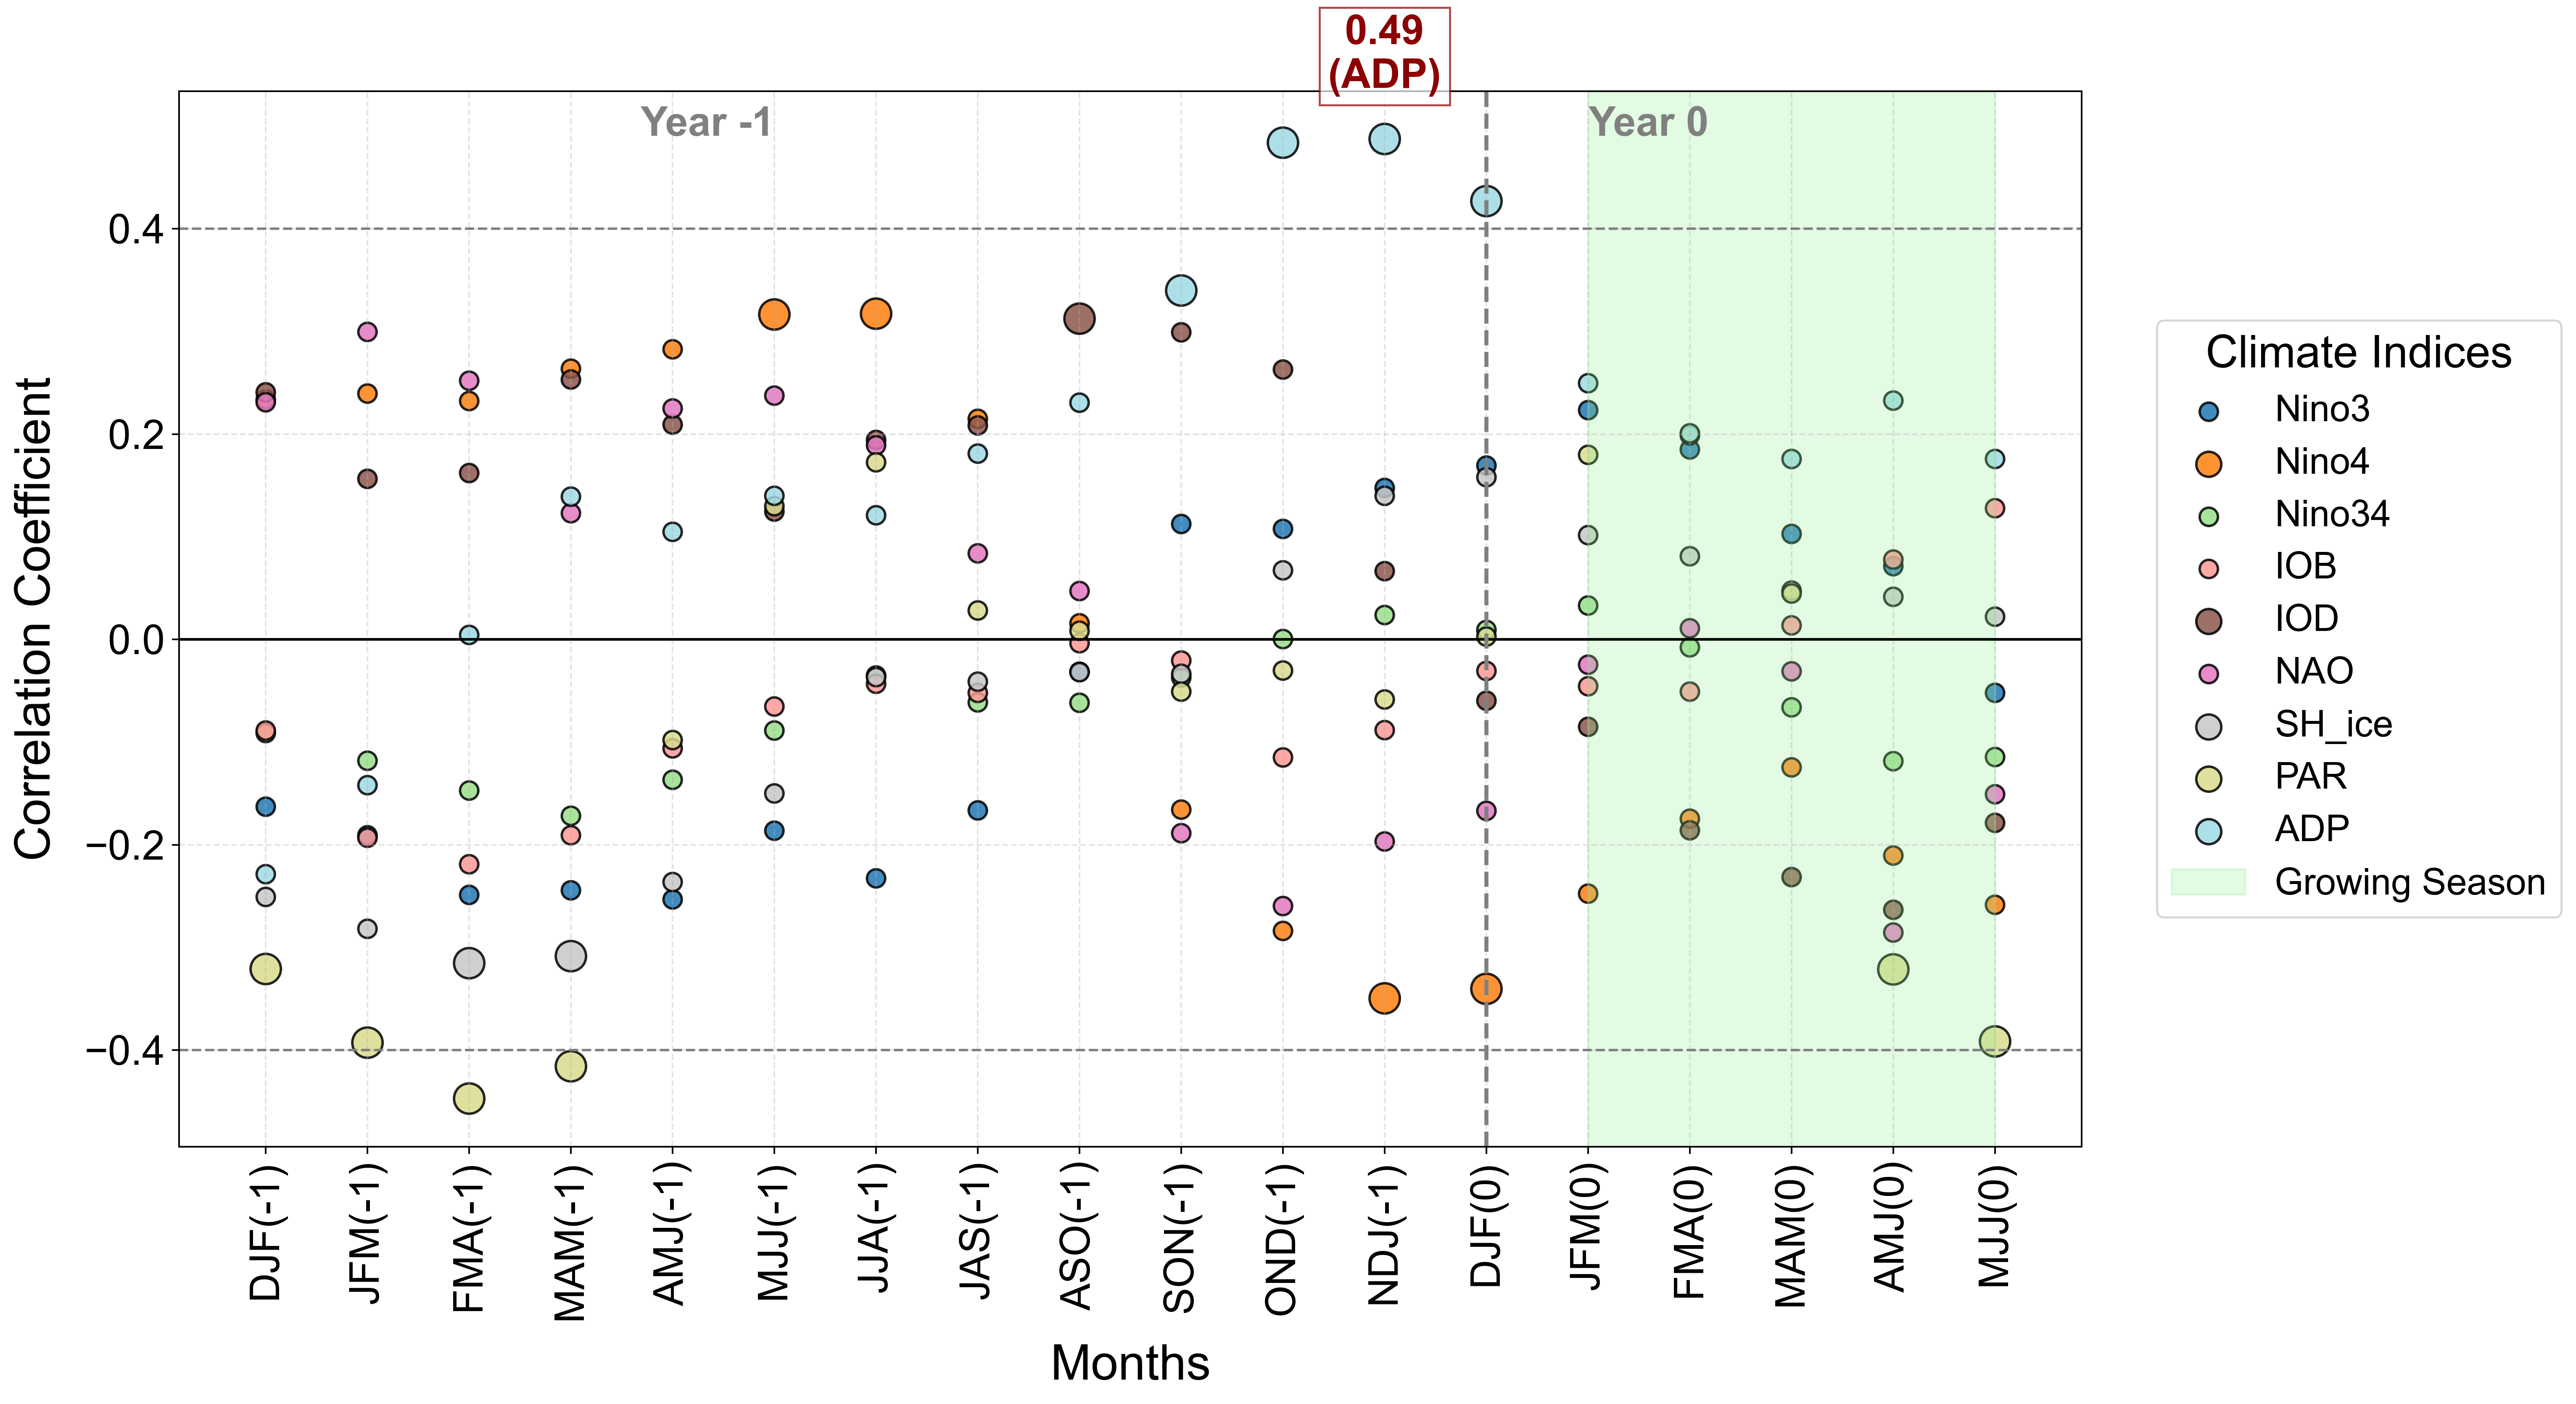

✅ Figure saved as /Volumes/limenghan/巴西玉米/论文图/Figure1_maize_BRA_DJFminus1_onwards_corr_globalmax_yearlabels_second.png


In [24]:
plot_correlations(df, p,area,crop,plant_date_data,harvest_date_data)                                               

In [25]:
df

,Nino3,Nino4,Nino34,IOB,IOD,NAO,SH_ice,Peninsula_Amundsen_Ross,Antarctic_Dipole
time,,,,,,,,,
DJF(-2),-0.108065,0.078629,0.127419,-0.058065,-0.375403,-0.029839,-0.218548,0.091129,-0.266935
JFM(-2),-0.128226,0.028226,0.14879,0.109677,-0.226613,-0.273387,0.027419,0.104839,-0.156855
FMA(-2),-0.116129,0.022984,0.185484,0.217339,-0.056048,-0.431048,-0.018548,0.183871,-0.279839
MAM(-2),-0.052823,-0.005645,0.166935,0.285081,0.143145,-0.417742,-0.060081,0.247581,-0.306855
AMJ(-2),-0.075403,0.06371,0.108065,0.221774,0.210081,-0.066935,-0.096371,0.275806,-0.241935
MJJ(-2),-0.077419,0.143145,0.069758,0.156452,0.242339,-0.031855,-0.125806,0.218145,-0.081855
JJA(-2),-0.110081,0.158871,0.017742,0.119355,0.153629,0.172177,-0.137097,0.116129,0.017339
JAS(-2),-0.08629,0.127419,-0.003226,0.159677,0.149194,-0.051613,-0.072177,0.079435,-0.034274
ASO(-2),-0.089516,0.189113,-0.032258,0.056048,0.050403,-0.029839,-0.099597,0.064113,-0.100806


In [26]:
total_yield = maize * da_maize_interp

# 假设 climate_df 的 index 是 MultiIndex(levels=['year', 'month'])
Antarctic_Dipole_df = df_processed.reset_index()[['year', 'month', 'Antarctic_Dipole']]

# 只取 ASO 月份
Antarctic_Dipole_df_OND = Antarctic_Dipole_df[Antarctic_Dipole_df['month'].isin([10, 11, 12])]

# 按年份取平均
Antarctic_Dipole_OND_1_average = Antarctic_Dipole_df_OND.groupby('year')['Antarctic_Dipole'].mean().to_frame(name='Antarctic_Dipole_OND_1_average')
Antarctic_Dipole_OND_1_average=Antarctic_Dipole_OND_1_average[4:-2]
Antarctic_Dipole_OND_1_average=(Antarctic_Dipole_OND_1_average-Antarctic_Dipole_OND_1_average.mean() )/ Antarctic_Dipole_OND_1_average.std()
Antarctic_Dipole_OND_1_average

In [110]:
##对不起呀对不起呀 前面算错了,先不改了

Antarctic_Dipole_OND_1_average=calculate_seasonal_standardized_mean(df_processed['Antarctic_Dipole'], 11, 1,1980,2015)
Antarctic_Dipole_OND_1_average=(Antarctic_Dipole_OND_1_average - Antarctic_Dipole_OND_1_average.mean()) / Antarctic_Dipole_OND_1_average.std()
Antarctic_Dipole_OND_1_average = Antarctic_Dipole_OND_1_average.to_frame(
    name='Antarctic_Dipole_OND_1_average'
)

In [111]:
Antarctic_Dipole_OND_1_average

,Antarctic_Dipole_OND_1_average
year,
1980,0.588371
1981,-0.102739
1982,-0.904108
1983,0.261572
1984,0.766755
1985,0.041002
1986,-0.607759
1987,-0.723235
1988,1.748914


In [112]:
from scipy import stats
#计算相关系数空间pattern
def reg_corr_location_with_merge(x_data, y_data):
    """
    对每个格点进行线性回归，使用 pandas.DataFrame 方式合并并处理 NaN 数据。
    :param x_data: 1D 数据 (时间序列)，可以是 xarray.DataArray 或 pandas.Series
    :param y_data: 3D 数据 (时间、纬度、经度)，xarray.DataArray
    :return: 包含回归斜率和 p 值的 xarray.Dataset
    """
    # 如果 x_data 是 xarray.DataArray，则转为 pandas.Series
    if isinstance(x_data, pd.Series):
        x_data = x_data.values
    elif isinstance(x_data, xr.DataArray):
        x_data = x_data.values
    x_data = x_data.iloc[:,0].values
    # 初始化结果数组
    reg_array = np.zeros((len(y_data.lat), len(y_data.lon))) * np.nan
    p_value_array = np.zeros((len(y_data.lat), len(y_data.lon))) * np.nan
    corr_array = np.zeros((len(y_data.lat), len(y_data.lon))) * np.nan
    pv_array = np.zeros((len(y_data.lat), len(y_data.lon))) * np.nan

    # 遍历每个格点
    for alon in range(len(y_data.lon)):
        for alat in range(len(y_data.lat)):
            # 提取当前格点的时间序列
            y_point = y_data.sel(lat=y_data.lat[alat], lon=y_data.lon[alon])
            # 如果 y_point 是 xarray.DataArray，则转为 pandas.Series
            if isinstance(y_point, xr.DataArray):
                y_point = y_point.to_series()
            y_point=y_point.values
            # 合并为一个 DataFrame
            merged_df= pd.DataFrame({'x': x_data, 'y': y_point}).dropna()  # 删除包含 NaN 的行

            # 如果有效数据点数大于 1，则计算回归
            if len(merged_df) > 1:
                slope, intercept, r_value, p_value, std_err = stats.linregress(
                    merged_df["x"].values, merged_df["y"].values
                )
                corr, pv = stats.spearmanr(
                    merged_df["x"].values, merged_df["y"].values
                )
                reg_array[alat, alon] = slope
                p_value_array[alat, alon] = p_value
                corr_array[alat, alon] = corr
                pv_array[alat, alon] = pv

    # 转换为 xarray.DataArray
    reg_array = xr.DataArray(
        reg_array, coords={"lat": y_data.lat, "lon": y_data.lon}, dims=["lat", "lon"]
    )
    p_value_array = xr.DataArray(
        p_value_array, coords={"lat": y_data.lat, "lon": y_data.lon}, dims=["lat", "lon"]
    )
    corr_array = xr.DataArray(
        corr_array, coords={"lat": y_data.lat, "lon": y_data.lon}, dims=["lat", "lon"]
    )
    pv_array = xr.DataArray(
        pv_array, coords={"lat": y_data.lat, "lon": y_data.lon}, dims=["lat", "lon"]
    )
    
    # 创建 xarray.Dataset
    reg_dataset = xr.Dataset(
        {"slope": reg_array, "pv": p_value_array},
        attrs={"description": "Regression Results"},
    )
    corr_dataset = xr.Dataset(
        {"corr": corr_array, "pv": pv_array},
        attrs={"description": "Correlation Results"},
    )
    return reg_dataset,corr_dataset
reg_maize_ano_Antarctic_Dipole,corr_maize_ano_Antarctic_Dipole=reg_corr_location_with_merge(Antarctic_Dipole_OND_1_average, maize_ano)

In [113]:
def extract_points_within_geodf(dataarray, geodf, crs="EPSG:4326"):
    """
    提取 GeoDataFrame 区域内的点（经纬度及其对应值）。
    
    :param dataarray: xarray.DataArray，维度为 time, lat, lon
    :param geodf: GeoDataFrame，包含目标区域的几何形状
    :param crs: GeoDataFrame 的坐标系，默认为 "EPSG:4326"
    :return: 包含区域内点的 DataArray
    """
    
    # 使用 meshgrid 创建经纬度网格
    lon, lat = np.meshgrid(dataarray.lon.values, dataarray.lat.values)
    da_coords = np.column_stack([lon.flatten(), lat.flatten()])
    points = [Point(lon, lat) for lon, lat in da_coords]  # 创建点对象列表
    
    # 通过 shapefile 构建区域掩膜
    region_mask = prep(geodf.geometry.unary_union)  # 使用 prepared geometries 加速查询
    valid_mask = np.array([region_mask.contains(point) for point in points]).reshape(dataarray.lat.size, dataarray.lon.size)
    
    # 应用掩膜到所有时间步
    crop_masked = dataarray.where(valid_mask)

    return crop_masked

In [114]:
from shapely.geometry import Point
from shapely.prepared import prep 
corr_maize_ano_Antarctic_Dipole_BRA= extract_points_within_geodf(corr_maize_ano_Antarctic_Dipole, BRA_shp)
reg_maize_ano_Antarctic_Dipole_BRA= extract_points_within_geodf(reg_maize_ano_Antarctic_Dipole, BRA_shp)

In [115]:
Brazil = gpd.read_file("/Users/limenghan/Desktop/地图/次国家/gadm41_BRA_shp/gadm41_BRA_1.shp")
Brazil.rename(columns={'NAME_1': 'loc'}, inplace=True)

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from shapely.prepared import prep

def mask_by_geodf(dataarray, geodf):
    lon, lat = np.meshgrid(dataarray.lon.values, dataarray.lat.values)
    points = [Point(x, y) for x, y in zip(lon.ravel(), lat.ravel())]
    region = prep(geodf.geometry.unary_union)
    inside = np.array([region.contains(p) for p in points]).reshape(len(dataarray.lat), len(dataarray.lon))
    return dataarray.where(inside)

def _to_2d(da):
    return da.mean("time") if ("time" in da.dims) else da

def plot_prod_and_reg_2panels(
    prod_mu_times_tpha,
    reg_pct_per_std,
    pval,
    BRA_shp,
    Brazil,
    sig_level=0.1,
    cmap_a="YlGn",
    cmap_b="PuOr",
    vmin_a=None, vmax_a=None,
    vmax_b=None,
    title_a="(a)",
    title_b="(b)",
    savepath=None,
    # ✅ 字体控制（你可以继续调大）
    base_font=20,
    title_font=26,
    cbar_label_font=22,
    cbar_tick_font=18
):
    # ✅ 全局字体更大
    plt.rcParams.update({
        "font.size": base_font,
        "axes.titlesize": title_font,
        "axes.labelsize": base_font + 2,
        "xtick.labelsize": base_font,
        "ytick.labelsize": base_font,
    })

    # (a) 产量：亩×t/ha -> tonne
    prod_tonne = _to_2d(prod_mu_times_tpha) / 15.0
    prod_tonne = mask_by_geodf(prod_tonne, BRA_shp)

    # (b) 回归：已处理好的 %/σ
    reg2d = mask_by_geodf(_to_2d(reg_pct_per_std), BRA_shp)
    pval2d = mask_by_geodf(_to_2d(pval), BRA_shp)

    fig, axes = plt.subplots(
        1, 2, figsize=(18, 8),
        subplot_kw={"projection": ccrs.PlateCarree()},
        dpi=350
    )

    # extent：巴西范围
    minx, miny, maxx, maxy = BRA_shp.total_bounds

    for ax in axes:
        ax.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.9)
        ax.add_feature(cfeature.BORDERS, linewidth=0.7)

        # 国家边界
        BRA_shp.boundary.plot(
            ax=ax, edgecolor="black", linewidth=1.2, facecolor="none",
            transform=ccrs.PlateCarree()
        )

        # 州界
        if Brazil is not None:
            Brazil.boundary.plot(
                ax=ax, edgecolor="gray", linewidth=0.7, facecolor="none",
                transform=ccrs.PlateCarree()
            )

    # (a) 产量
    ax0 = axes[0]
    mesh0 = ax0.pcolormesh(
        prod_tonne.lon, prod_tonne.lat, prod_tonne,
        transform=ccrs.PlateCarree(),
        cmap=cmap_a, shading="auto",
        vmin=vmin_a, vmax=vmax_a
    )
    cb0 = plt.colorbar(mesh0, ax=ax0, shrink=0.82)
    cb0.set_label("tonne", fontsize=cbar_label_font)
    cb0.ax.tick_params(labelsize=cbar_tick_font)
    ax0.set_title(title_a, loc="left", fontweight="bold")

    # (b) 回归
    ax1 = axes[1]
    if vmax_b is None:
        vmax_b = np.nanmax(np.abs(reg2d.values))
        if not np.isfinite(vmax_b) or vmax_b == 0:
            vmax_b = 1.0

    mesh1 = ax1.pcolormesh(
        reg2d.lon, reg2d.lat, reg2d,
        transform=ccrs.PlateCarree(),
        cmap=cmap_b, shading="auto",
        vmin=-vmax_b, vmax=vmax_b
    )
    cb1 = plt.colorbar(mesh1, ax=ax1, shrink=0.82)
    cb1.set_label("% / σ", fontsize=cbar_label_font)
    cb1.ax.tick_params(labelsize=cbar_tick_font)
    ax1.set_title(title_b, loc="left", fontweight="bold")

    # 显著性斜线：p < sig_level
    sig_mask = (pval2d < sig_level).where(np.isfinite(pval2d), other=False)
    ax1.contourf(
        reg2d.lon, reg2d.lat, sig_mask,
        levels=[0.5, 1.5], hatches=["///"], colors="none",
        transform=ccrs.PlateCarree(), alpha=0
    )

    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=350, bbox_inches="tight")
        print(f"✅ saved: {savepath}")
    filename = f"/Volumes/limenghan/巴西玉米/论文图/Figure2_maize_BRA_OND_1_pattern_second.png"
    plt.savefig(filename, dpi=350, bbox_inches='tight')
    plt.show()


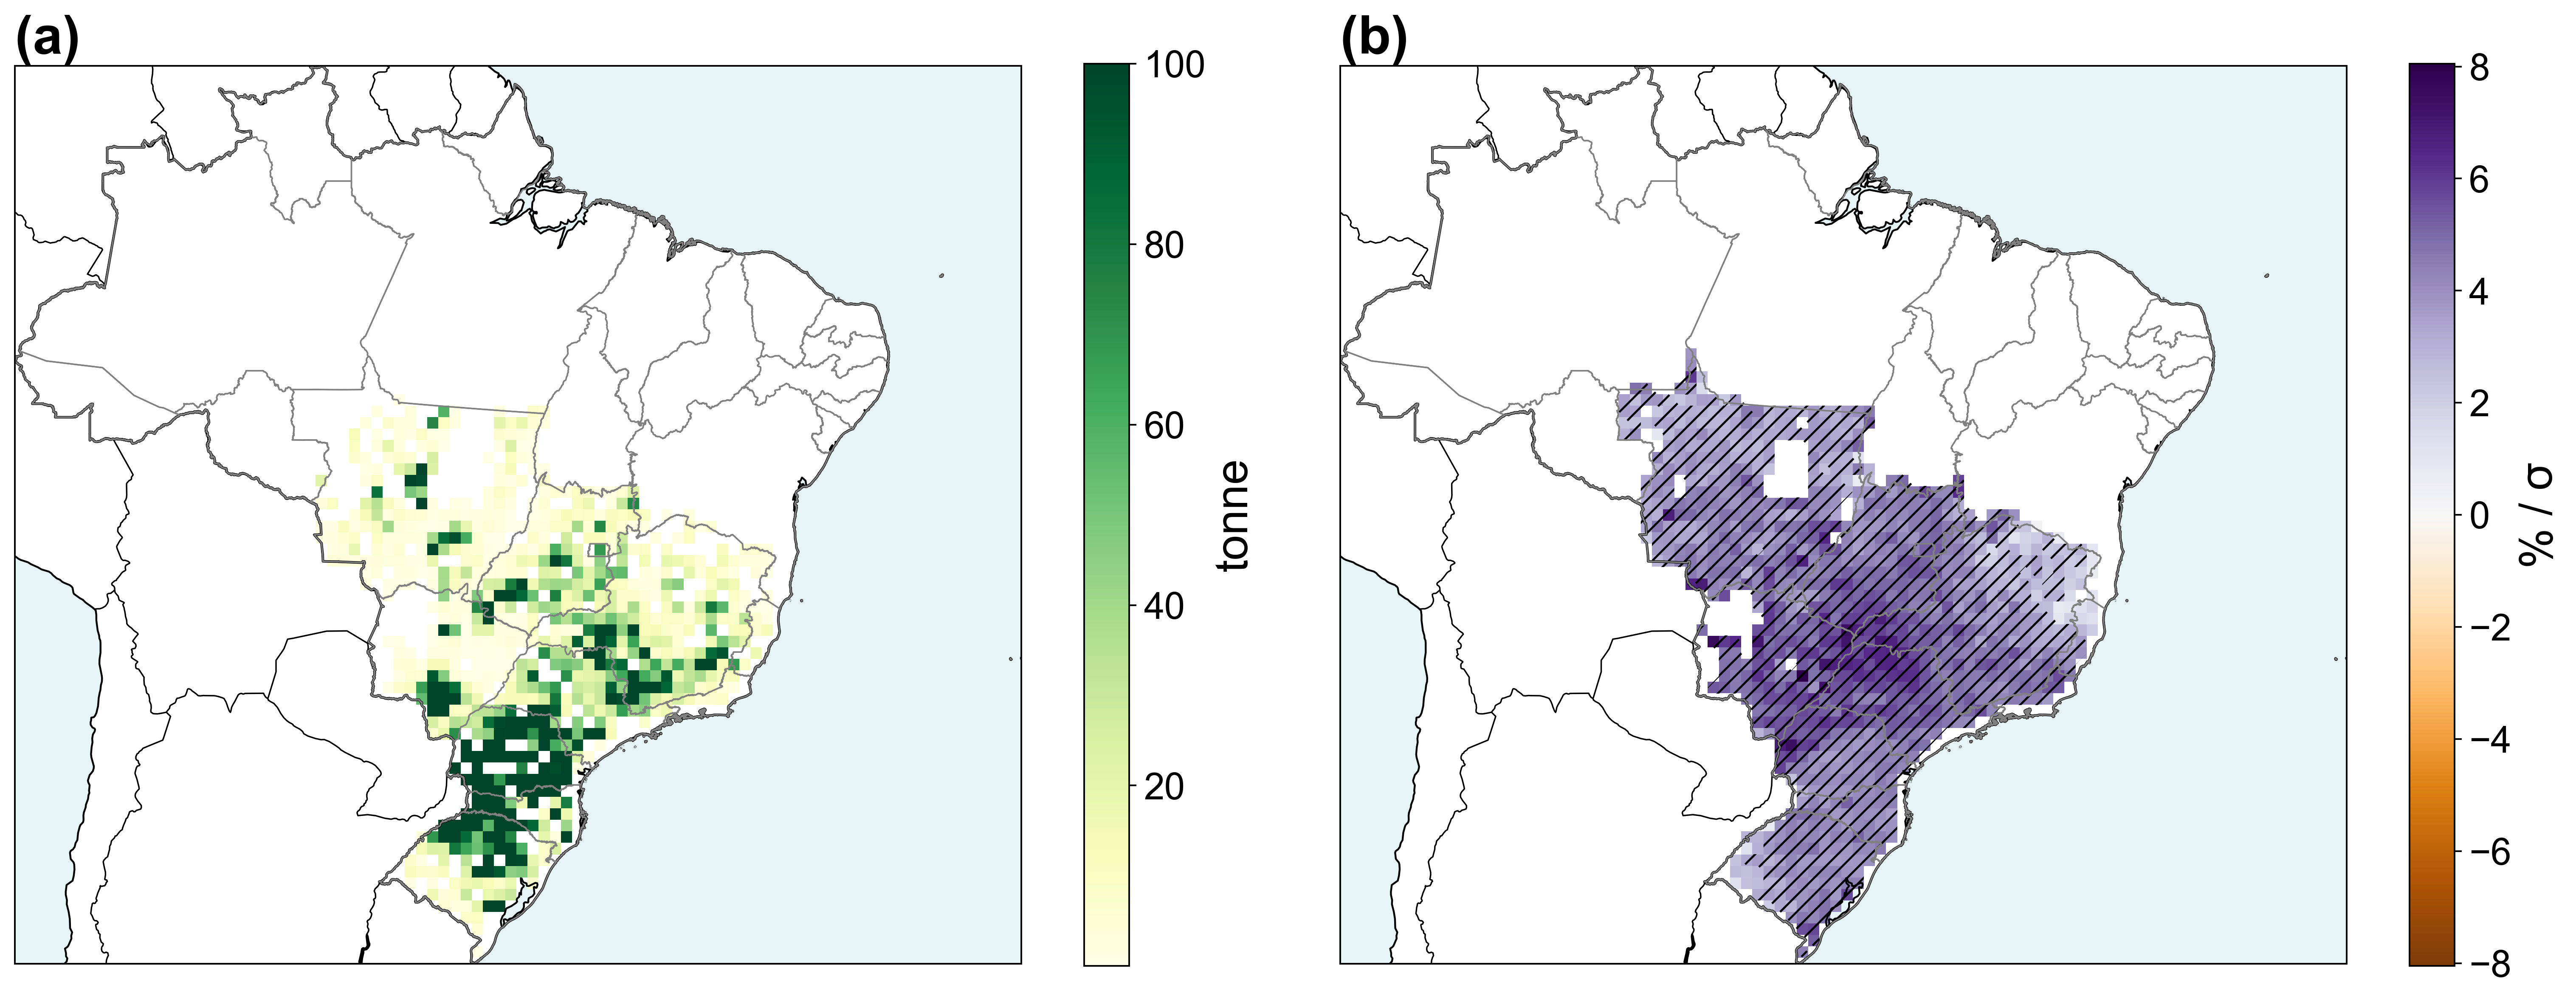

In [117]:

plot_prod_and_reg_2panels(
    total_yield,     # 亩 * (t/ha) 的产量 DataArray（或你自己确认的同类数据）
    reg_maize_ano_Antarctic_Dipole_BRA['slope'],                   # 回归 slope 的 DataArray（与 prod 同网格）
    reg_maize_ano_Antarctic_Dipole_BRA['pv'],             # p值 DataArray（与 reg 同网格）
    BRA_shp,
    Brazil,
    sig_level=0.1,
    cmap_a="YlGn",
    cmap_b="PuOr",
    vmin_a=None, vmax_a=100,
    vmax_b=None,            # 默认自动对称
    title_a="(a) ",
    title_b="(b) ",
    savepath=None
)

<Axes: >

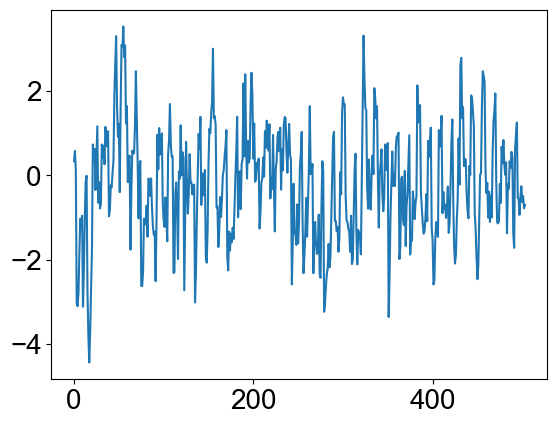

In [118]:
Antarctic_Dipole_df['Antarctic_Dipole'].plot()

<Axes: xlabel='year'>

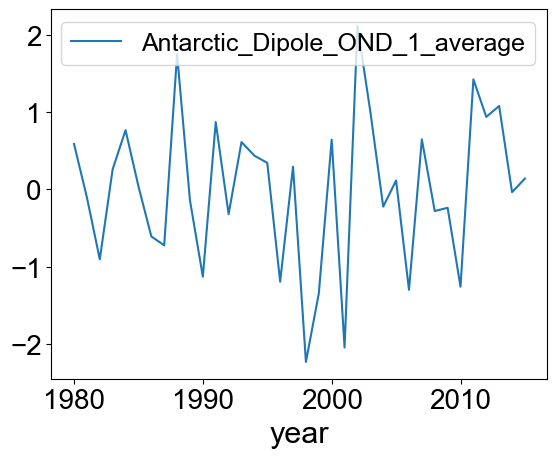

In [119]:
Antarctic_Dipole_OND_1_average.plot()

In [120]:
total_yield_Brazil=extract_points_within_geodf(total_yield, BRA_shp)
total_yield_Brazil

<xarray.DataArray (time: 36, lat: 360, lon: 720)>
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]])
Coordinates:
  * lat      (lat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * time     (time) int64 1981 1982 1983 1984 1985 ... 2012 2013 2014 2015 2016
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

In [121]:
total_yield_Brazil=extract_points_within_geodf(total_yield, BRA_shp)

In [122]:
(3.167686e+05+3.223771e+05+3.279260e+05+3.674363e+05+3.515026e+05)/5

337202.12

In [123]:
total_yield_Brazil_sum = total_yield_Brazil.sum(dim=['lat', 'lon'], skipna=True)
total_yield_Brazil_sum = total_yield_Brazil_sum.to_series()
total_yield_Brazil_sum=total_yield_Brazil_sum.iloc[1:]
total_yield_Brazil_sum

time
1982    3.167686e+05
1983    3.223771e+05
1984    3.279260e+05
1985    3.674363e+05
1986    3.515026e+05
1987    3.809469e+05
1988    3.304549e+05
1989    4.512942e+05
1990    4.025946e+05
1991    3.564673e+05
1992    4.279719e+05
1993    4.408879e+05
1994    3.754156e+05
1995    5.324373e+05
1996    5.542952e+05
1997    5.300182e+05
1998    5.540886e+05
1999    5.233666e+05
2000    5.180018e+05
2001    6.746055e+05
2002    5.686808e+05
2003    7.719321e+05
2004    6.411519e+05
2005    6.013757e+05
2006    6.509691e+05
2007    7.508573e+05
2008    7.871870e+05
2009    7.432517e+05
2010    8.638941e+05
2011    8.194627e+05
2012    1.003963e+06
2013    1.005230e+06
2014    9.613307e+05
2015    1.647773e+06
2016    8.645069e+05
dtype: float64

In [124]:
trend_5yr

time
1982    3.223572e+05
1983    3.336270e+05
1984    3.372021e+05
1985    3.500378e+05
1986    3.516533e+05
1987    3.763270e+05
1988    3.833586e+05
1989    3.843516e+05
1990    3.937566e+05
1991    4.158432e+05
1992    4.006675e+05
1993    4.266360e+05
1994    4.662016e+05
1995    4.866108e+05
1996    5.092510e+05
1997    5.388412e+05
1998    5.359541e+05
1999    5.600161e+05
2000    5.677487e+05
2001    6.113174e+05
2002    6.348744e+05
2003    6.515492e+05
2004    6.468219e+05
2005    6.832572e+05
2006    6.863082e+05
2007    7.067281e+05
2008    7.592318e+05
2009    7.929306e+05
2010    8.435516e+05
2011    8.871601e+05
2012    9.307759e+05
2013    1.087552e+06
2014    1.096560e+06
2015    1.119710e+06
2016    1.157870e+06
dtype: float64

In [125]:
trend_5yr = total_yield_Brazil_sum.rolling(window=5, center=True, min_periods=3).mean()

total_yield_Brazil_sum_anomaly = total_yield_Brazil_sum - trend_5yr
total_yield_Brazil_sum_anomaly 

time
1982     -5588.626337
1983    -11249.896526
1984     -9276.119024
1985     17398.503842
1986      -150.713237
1987      4619.889120
1988    -52903.745591
1989     66942.650592
1990      8838.024765
1991    -59375.936083
1992     27304.480182
1993     14251.936748
1994    -90786.027326
1995     45826.438846
1996     45044.279622
1997     -8822.979327
1998     18134.488654
1999    -36649.551805
2000    -49746.885262
2001     63288.162706
2002    -66193.576475
2003    120382.909805
2004     -5670.062901
2005    -81881.544634
2006    -35339.090830
2007     44129.201240
2008     27955.128728
2009    -49678.909833
2010     20342.524473
2011    -67697.404223
2012     73186.654663
2013    -82322.118459
2014   -135229.768602
2015    528062.691238
2016   -293363.167237
dtype: float64

In [126]:
total_yield_Brazil_sum.mean()

612012.0511171067

In [127]:
Antarctic_Dipole_OND_1_average

,Antarctic_Dipole_OND_1_average
year,
1980,0.588371
1981,-0.102739
1982,-0.904108
1983,0.261572
1984,0.766755
1985,0.041002
1986,-0.607759
1987,-0.723235
1988,1.748914


In [128]:
Antarctic_Dipole_OND_1_average_iloc=Antarctic_Dipole_OND_1_average.iloc[1:]
Antarctic_Dipole_OND_1_average_iloc

,Antarctic_Dipole_OND_1_average
year,
1981,-0.102739
1982,-0.904108
1983,0.261572
1984,0.766755
1985,0.041002
1986,-0.607759
1987,-0.723235
1988,1.748914
1989,-0.141903


In [129]:

import statsmodels.api as sm

# 1. 创建 DataFrame
df = pd.DataFrame({
    'x': Antarctic_Dipole_OND_1_average_iloc['Antarctic_Dipole_OND_1_average'].values,
    'y': total_yield_Brazil_sum_anomaly.values
})

# 2. 去掉缺测值
df = df.dropna()

# 3. 回归：y ~ x
X = sm.add_constant(df['x'])   # 加截距项
y = df['y']

model = sm.OLS(y, X).fit()

# 4. 输出结果
print(df)
print(model.summary())

           x              y
0  -0.102739   -5588.626337
1  -0.904108  -11249.896526
2   0.261572   -9276.119024
3   0.766755   17398.503842
4   0.041002    -150.713237
5  -0.607759    4619.889120
6  -0.723235  -52903.745591
7   1.748914   66942.650592
8  -0.141903    8838.024765
9  -1.128484  -59375.936083
10  0.871293   27304.480182
11 -0.320225   14251.936748
12  0.613111  -90786.027326
13  0.436773   45826.438846
14  0.343788   45044.279622
15 -1.193794   -8822.979327
16  0.294784   18134.488654
17 -2.231587  -36649.551805
18 -1.347054  -49746.885262
19  0.643514   63288.162706
20 -2.044951  -66193.576475
21  2.115305  120382.909805
22  1.007260   -5670.062901
23 -0.222683  -81881.544634
24  0.115587  -35339.090830
25 -1.299055   44129.201240
26  0.647437   27955.128728
27 -0.279629  -49678.909833
28 -0.237439   20342.524473
29 -1.258600  -67697.404223
30  1.424559   73186.654663
31  0.938097  -82322.118459
32  1.079903 -135229.768602
33 -0.035405  528062.691238
34  0.140624 -293363

In [142]:
2.074e+04 /604585.731873435

0.03430448141032503

In [131]:
2.123e+04

21230.0

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
from shapely.prepared import prep
import xarray as xr
import pandas as pd


# =========================================================
# 通用函数
# =========================================================
def zero_to_nan(da):
    """把 DataArray 中等于 0 的值变成 NaN"""
    return da.where(da != 0)


def mask_by_geodf(dataarray, geodf):
    lon, lat = np.meshgrid(dataarray.lon.values, dataarray.lat.values)
    points = [Point(x, y) for x, y in zip(lon.ravel(), lat.ravel())]
    region = prep(geodf.geometry.unary_union)
    inside = np.array(
        [region.contains(p) or region.covers(p) for p in points]
    ).reshape(len(dataarray.lat), len(dataarray.lon))
    return dataarray.where(inside)


def _to_2d(da):
    return da.mean("time") if ("time" in da.dims) else da


def add_south_polar_circle(ax):
    theta = np.linspace(0, 2 * np.pi, 400)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)


def plot_lat_arc(ax, lon1, lon2, lat, color='r', lw=2, n=500):
    lons = np.linspace(lon1, lon2, n)
    lats = np.full_like(lons, lat, dtype=float)
    ax.plot(lons, lats, color=color, linewidth=lw,
            transform=ccrs.PlateCarree(), zorder=5)


def plot_lon_arc(ax, lon, lat1, lat2, color='r', lw=2, n=400):
    lats = np.linspace(lat1, lat2, n)
    lons = np.full_like(lats, lon, dtype=float)
    ax.plot(lons, lats, color=color, linewidth=lw,
            transform=ccrs.PlateCarree(), zorder=5)


def add_polar_labels(ax):
    for lat in [-50, -60, -70, -80]:
        ax.text(
            135, lat, f"{abs(lat)}°S",
            transform=ccrs.PlateCarree(),
            fontsize=11, color="gray", ha="center", va="center"
        )

    lon_labels = [
        (0, "0°"),
        (60, "60°E"),
        (120, "120°E"),
        (180, "180°"),
        (-120, "120°W"),
        (-60, "60°W"),
    ]
    for lon, label in lon_labels:
        ax.text(
            lon, -47, label,
            transform=ccrs.PlateCarree(),
            fontsize=11, color="gray", ha="center", va="center"
        )


def _to_series_keep_index(obj):
    """把输入转成 pandas.Series，尽量保留原索引"""
    if hasattr(obj, "to_series"):
        s = obj.to_series()
    elif isinstance(obj, pd.Series):
        s = obj.copy()
    else:
        s = pd.Series(obj)
    return s


# =========================================================
# 主函数
# =========================================================
def plot_adi_4panels(
    Antarctic_Dipole_OND_1_average,
    total_yield_Brazil_sum_anomaly,
    prod_mu_times_tpha,
    reg_pct_per_std,
    pval,
    BRA_shp,
    Brazil,
    savepath=None,
    sig_level=0.1,
    cmap_c="YlGn",
    cmap_d="PuOr",
    base_font=18,
    title_font=22,
    cbar_label_font=18,
    cbar_tick_font=15
):
    # 全局字体
    plt.rcParams.update({
        "font.size": base_font,
        "axes.titlesize": title_font,
        "axes.labelsize": base_font,
        "xtick.labelsize": base_font - 2,
        "ytick.labelsize": base_font - 2,
        "font.family": "Arial",
        "text.color": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black"
    })

    # -------------------------
    # b 图时间序列
    # x 轴完全以 ADP 为准
    # yield 可以缺值，用 NaN 保留年份
    # -------------------------
    adi_series = _to_series_keep_index(Antarctic_Dipole_OND_1_average).dropna()
    yield_series = _to_series_keep_index(total_yield_Brazil_sum_anomaly)

    # 按你的要求仍然裁掉前后 2 个
    yield_series = yield_series.iloc[1:-2]

    # 用 ADP 的索引作为最终 x 轴
    xvals = adi_series.index
    yvals = adi_series.values

    # 把 yield 重建到 ADP 的 x 轴上，缺失年份自动为 NaN
    yield_series = yield_series.reindex(xvals)
    yield_vals = yield_series.values

    pos_mask = yvals >= 1.5
    neg_mask = yvals <= -1.5

    # 提取年份
    year_vals = np.array([v.year if hasattr(v, "year") else int(v) for v in xvals])

    red_years = np.array([1989,2003])
    blue_years = np.array([1999,2002])

    red_mask_years = np.isin(year_vals, red_years) & np.isfinite(yield_vals)
    blue_mask_years = np.isin(year_vals, blue_years) & np.isfinite(yield_vals)

    # -------------------------
    # c、d 数据处理
    # -------------------------
    prod_tonne = _to_2d(prod_mu_times_tpha) / 15.0
    prod_tonne = zero_to_nan(prod_tonne)
    prod_tonne = mask_by_geodf(prod_tonne, BRA_shp)

    reg2d = zero_to_nan(_to_2d(reg_pct_per_std))
    reg2d = mask_by_geodf(reg2d, BRA_shp)

    pval2d = _to_2d(pval)
    pval2d = mask_by_geodf(pval2d, BRA_shp)

    # -------------------------
    # 建图
    # -------------------------
    fig = plt.figure(figsize=(16, 12), dpi=350)
    gs = fig.add_gridspec(2, 2, hspace=0.18, wspace=0.12)

    # =====================================================
    # (a) Antarctic map
    # =====================================================
    ax1 = fig.add_subplot(gs[0, 0], projection=ccrs.SouthPolarStereo())
    ax1.set_extent([-180, 180, -90, -45], crs=ccrs.PlateCarree())
    add_south_polar_circle(ax1)

    ax1.add_feature(cfeature.LAND, facecolor="lightgray")
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.6)

    gl = ax1.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=False,
        linewidth=0.6,
        color='gray',
        alpha=0.6,
        linestyle='--'
    )
    gl.xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120, 180])
    gl.ylocator = mticker.FixedLocator([-80, -70, -60, -50])

    add_polar_labels(ax1)

    # Weddell
    plot_lat_arc(ax1, -70, 20, -50, color='red', lw=2.2, n=500)
    plot_lat_arc(ax1, -70, 20, -70, color='red', lw=2.2, n=500)
    plot_lon_arc(ax1, -70, -70, -50, color='red', lw=2.2, n=400)
    plot_lon_arc(ax1, 20, -70, -50, color='red', lw=2.2, n=400)
    ax1.text(
        -25, -58, "Weddell",
        color="red", fontsize=13, fontweight="bold",
        transform=ccrs.PlateCarree(), ha="center", va="center"
    )

    # Ross
    plot_lat_arc(ax1, 160, 180, -50, color='blue', lw=2.2, n=300)
    plot_lat_arc(ax1, -180, -130, -50, color='blue', lw=2.2, n=300)
    plot_lat_arc(ax1, 160, 180, -70, color='blue', lw=2.2, n=300)
    plot_lat_arc(ax1, -180, -130, -70, color='blue', lw=2.2, n=300)
    plot_lon_arc(ax1, 160, -70, -50, color='blue', lw=2.2, n=400)
    plot_lon_arc(ax1, -130, -70, -50, color='blue', lw=2.2, n=400)
    ax1.text(
        175, -58, "Ross",
        color="blue", fontsize=13, fontweight="bold",
        transform=ccrs.PlateCarree(), ha="center", va="center"
    )

    ax1.set_title("(a)", loc="left", fontweight="bold")

        # =====================================================
    # (b) Standardized ADP + total yield anomaly
    # =====================================================
    ax2 = fig.add_subplot(gs[0, 1])

    # 左轴：ADP
    line1, = ax2.plot(
        xvals, yvals,
        color="black", linewidth=1.6, label="ADP"
    )
    ax2.axhline(0, color="black", linewidth=1.0)
    ax2.axhline(1.5, color="gray", linestyle="--", linewidth=1.2)
    ax2.axhline(-1.5, color="gray", linestyle="--", linewidth=1.2)

    # ADP 点改为实心
    sc1 = ax2.scatter(
        np.array(xvals)[pos_mask], yvals[pos_mask],
        color="red", s=42, linewidths=0.8, zorder=3, label="ADP ≥ 1.5 SD"
    )
    sc2 = ax2.scatter(
        np.array(xvals)[neg_mask], yvals[neg_mask],
        color="blue", s=42, linewidths=0.8, zorder=3, label="ADP ≤ -1.5 SD"
    )

    ax2.set_ylabel("Standardized ADP", color="black")
    ax2.tick_params(axis="y", colors="black")
    ax2.tick_params(axis="x", colors="black")
    ax2.grid(True, linestyle="--", alpha=0.35)

    # 左轴建议也设成关于 0 对称，视觉更稳
    y1_abs = np.nanmax(np.abs(yvals))
    y1_abs = max(y1_abs, 1.2)   # 至少保证 ±1 能舒服显示
    ax2.set_ylim(-y1_abs * 1.1, y1_abs * 1.1)

    # 右轴：yield anomaly，允许缺值
    ax2r = ax2.twinx()
    line2, = ax2r.plot(
        xvals, yield_vals,
        color="black", linewidth=1.8, linestyle="--",
        label="Total yield anomaly"
    )

    # 年份标记：只在有 yield 值的年份上画
    ax2r.scatter(
        np.array(xvals)[red_mask_years], yield_vals[red_mask_years],
        facecolors="none", edgecolors="red", s=70, linewidths=1.8,
        zorder=4
    )
    ax2r.scatter(
        np.array(xvals)[blue_mask_years], yield_vals[blue_mask_years],
        facecolors="none", edgecolors="blue", s=70, linewidths=1.8,
        zorder=4
    )

    ax2r.set_ylabel("Total yield anomaly (tonnes)", color="black")
    ax2r.tick_params(axis="y", colors="black")

    # ===== 关键：右轴也设成围绕 0 对称，这样 0 自动对齐 =====
    y2_abs = np.nanmax(np.abs(yield_vals[np.isfinite(yield_vals)]))
    if not np.isfinite(y2_abs) or y2_abs == 0:
        y2_abs = 1.0
    ax2r.set_ylim(-y2_abs * 1.1, y2_abs * 1.1)

    ax2.set_title("(b)", loc="left", fontweight="bold", color="black")

    # 图例不写空心点年份标记
    handles = [line1, sc1, sc2, line2]
    labels = [h.get_label() for h in handles]
    ax2.legend(
        handles, labels,
        frameon=False, fontsize=11, loc="lower left"
    )
    # =====================================================
    # (c) Total maize production
    # =====================================================
    ax3 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())

    minx, miny, maxx, maxy = BRA_shp.total_bounds
    ax3.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
    ax3.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
    ax3.add_feature(cfeature.COASTLINE, linewidth=0.9)
    ax3.add_feature(cfeature.BORDERS, linewidth=0.7)

    ax3.add_geometries(
        BRA_shp.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=1.2,
        zorder=4
    )

    if Brazil is not None:
        ax3.add_geometries(
            Brazil.geometry,
            crs=ccrs.PlateCarree(),
            facecolor="none",
            edgecolor="gray",
            linewidth=0.7,
            zorder=4
        )

    mesh0 = ax3.pcolormesh(
        prod_tonne.lon, prod_tonne.lat, prod_tonne,
        transform=ccrs.PlateCarree(),
        cmap=cmap_c, shading="auto",
        vmin=0, vmax=5000
    )
    cb0 = plt.colorbar(mesh0, ax=ax3, shrink=0.82)
    cb0.set_label("tonne", fontsize=cbar_label_font)
    cb0.ax.tick_params(labelsize=cbar_tick_font)
    ax3.set_title("(c)", loc="left", fontweight="bold")

    # =====================================================
    # (d) Regression map
    # =====================================================
    ax4 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())

    ax4.set_extent([minx, maxx, miny, maxy], crs=ccrs.PlateCarree())
    ax4.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.3)
    ax4.add_feature(cfeature.COASTLINE, linewidth=0.9)
    ax4.add_feature(cfeature.BORDERS, linewidth=0.7)

    ax4.add_geometries(
        BRA_shp.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=1.2,
        zorder=4
    )

    if Brazil is not None:
        ax4.add_geometries(
            Brazil.geometry,
            crs=ccrs.PlateCarree(),
            facecolor="none",
            edgecolor="gray",
            linewidth=0.7,
            zorder=4
        )

    vmax_b = np.nanmax(np.abs(reg2d.values))
    if not np.isfinite(vmax_b) or vmax_b == 0:
        vmax_b = 1.0

    mesh1 = ax4.pcolormesh(
        reg2d.lon, reg2d.lat, reg2d,
        transform=ccrs.PlateCarree(),
        cmap=cmap_d, shading="auto",
        vmin=-vmax_b, vmax=vmax_b
    )
    cb1 = plt.colorbar(mesh1, ax=ax4, shrink=0.82)
    cb1.set_label("% / σ", fontsize=cbar_label_font)
    cb1.ax.tick_params(labelsize=cbar_tick_font)
    ax4.set_title("(d)", loc="left", fontweight="bold")

    # 显著性斜线：p < sig_level
    sig_mask = (pval2d < sig_level).where(np.isfinite(pval2d), other=False)
    ax4.contourf(
        reg2d.lon, reg2d.lat, sig_mask,
        levels=[0.5, 1.5], hatches=["///"], colors="none",
        transform=ccrs.PlateCarree(), alpha=0
    )

    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=350, bbox_inches="tight")
        print(f"✅ saved: {savepath}")

    filename = "/Volumes/limenghan/巴西玉米/论文图/Figure2_maize_BRA_NDJ_1_pattern_second.png"
    plt.savefig(filename, dpi=350, bbox_inches='tight')
    plt.show()

In [134]:

total_yield_mean= total_yield_Brazil.sum(dim=['time'], skipna=True)

total_yield_mean= total_yield_mean.where(total_yield_mean!= 0)

In [135]:
Antarctic_Dipole_OND_1_average['Antarctic_Dipole_OND_1_average']>1.5

year
1980    False
1981    False
1982    False
1983    False
1984    False
1985    False
1986    False
1987    False
1988     True
1989    False
1990    False
1991    False
1992    False
1993    False
1994    False
1995    False
1996    False
1997    False
1998    False
1999    False
2000    False
2001    False
2002     True
2003    False
2004    False
2005    False
2006    False
2007    False
2008    False
2009    False
2010    False
2011    False
2012    False
2013    False
2014    False
2015    False
Name: Antarctic_Dipole_OND_1_average, dtype: bool

In [136]:
total_yield_Brazil_sum_anomaly[1:-3]

time
1983    -11249.896526
1984     -9276.119024
1985     17398.503842
1986      -150.713237
1987      4619.889120
1988    -52903.745591
1989     66942.650592
1990      8838.024765
1991    -59375.936083
1992     27304.480182
1993     14251.936748
1994    -90786.027326
1995     45826.438846
1996     45044.279622
1997     -8822.979327
1998     18134.488654
1999    -36649.551805
2000    -49746.885262
2001     63288.162706
2002    -66193.576475
2003    120382.909805
2004     -5670.062901
2005    -81881.544634
2006    -35339.090830
2007     44129.201240
2008     27955.128728
2009    -49678.909833
2010     20342.524473
2011    -67697.404223
2012     73186.654663
2013    -82322.118459
dtype: float64

In [137]:
total_yield_mean

<xarray.DataArray (lat: 360, lon: 720)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * lat      (lat) float64 -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8

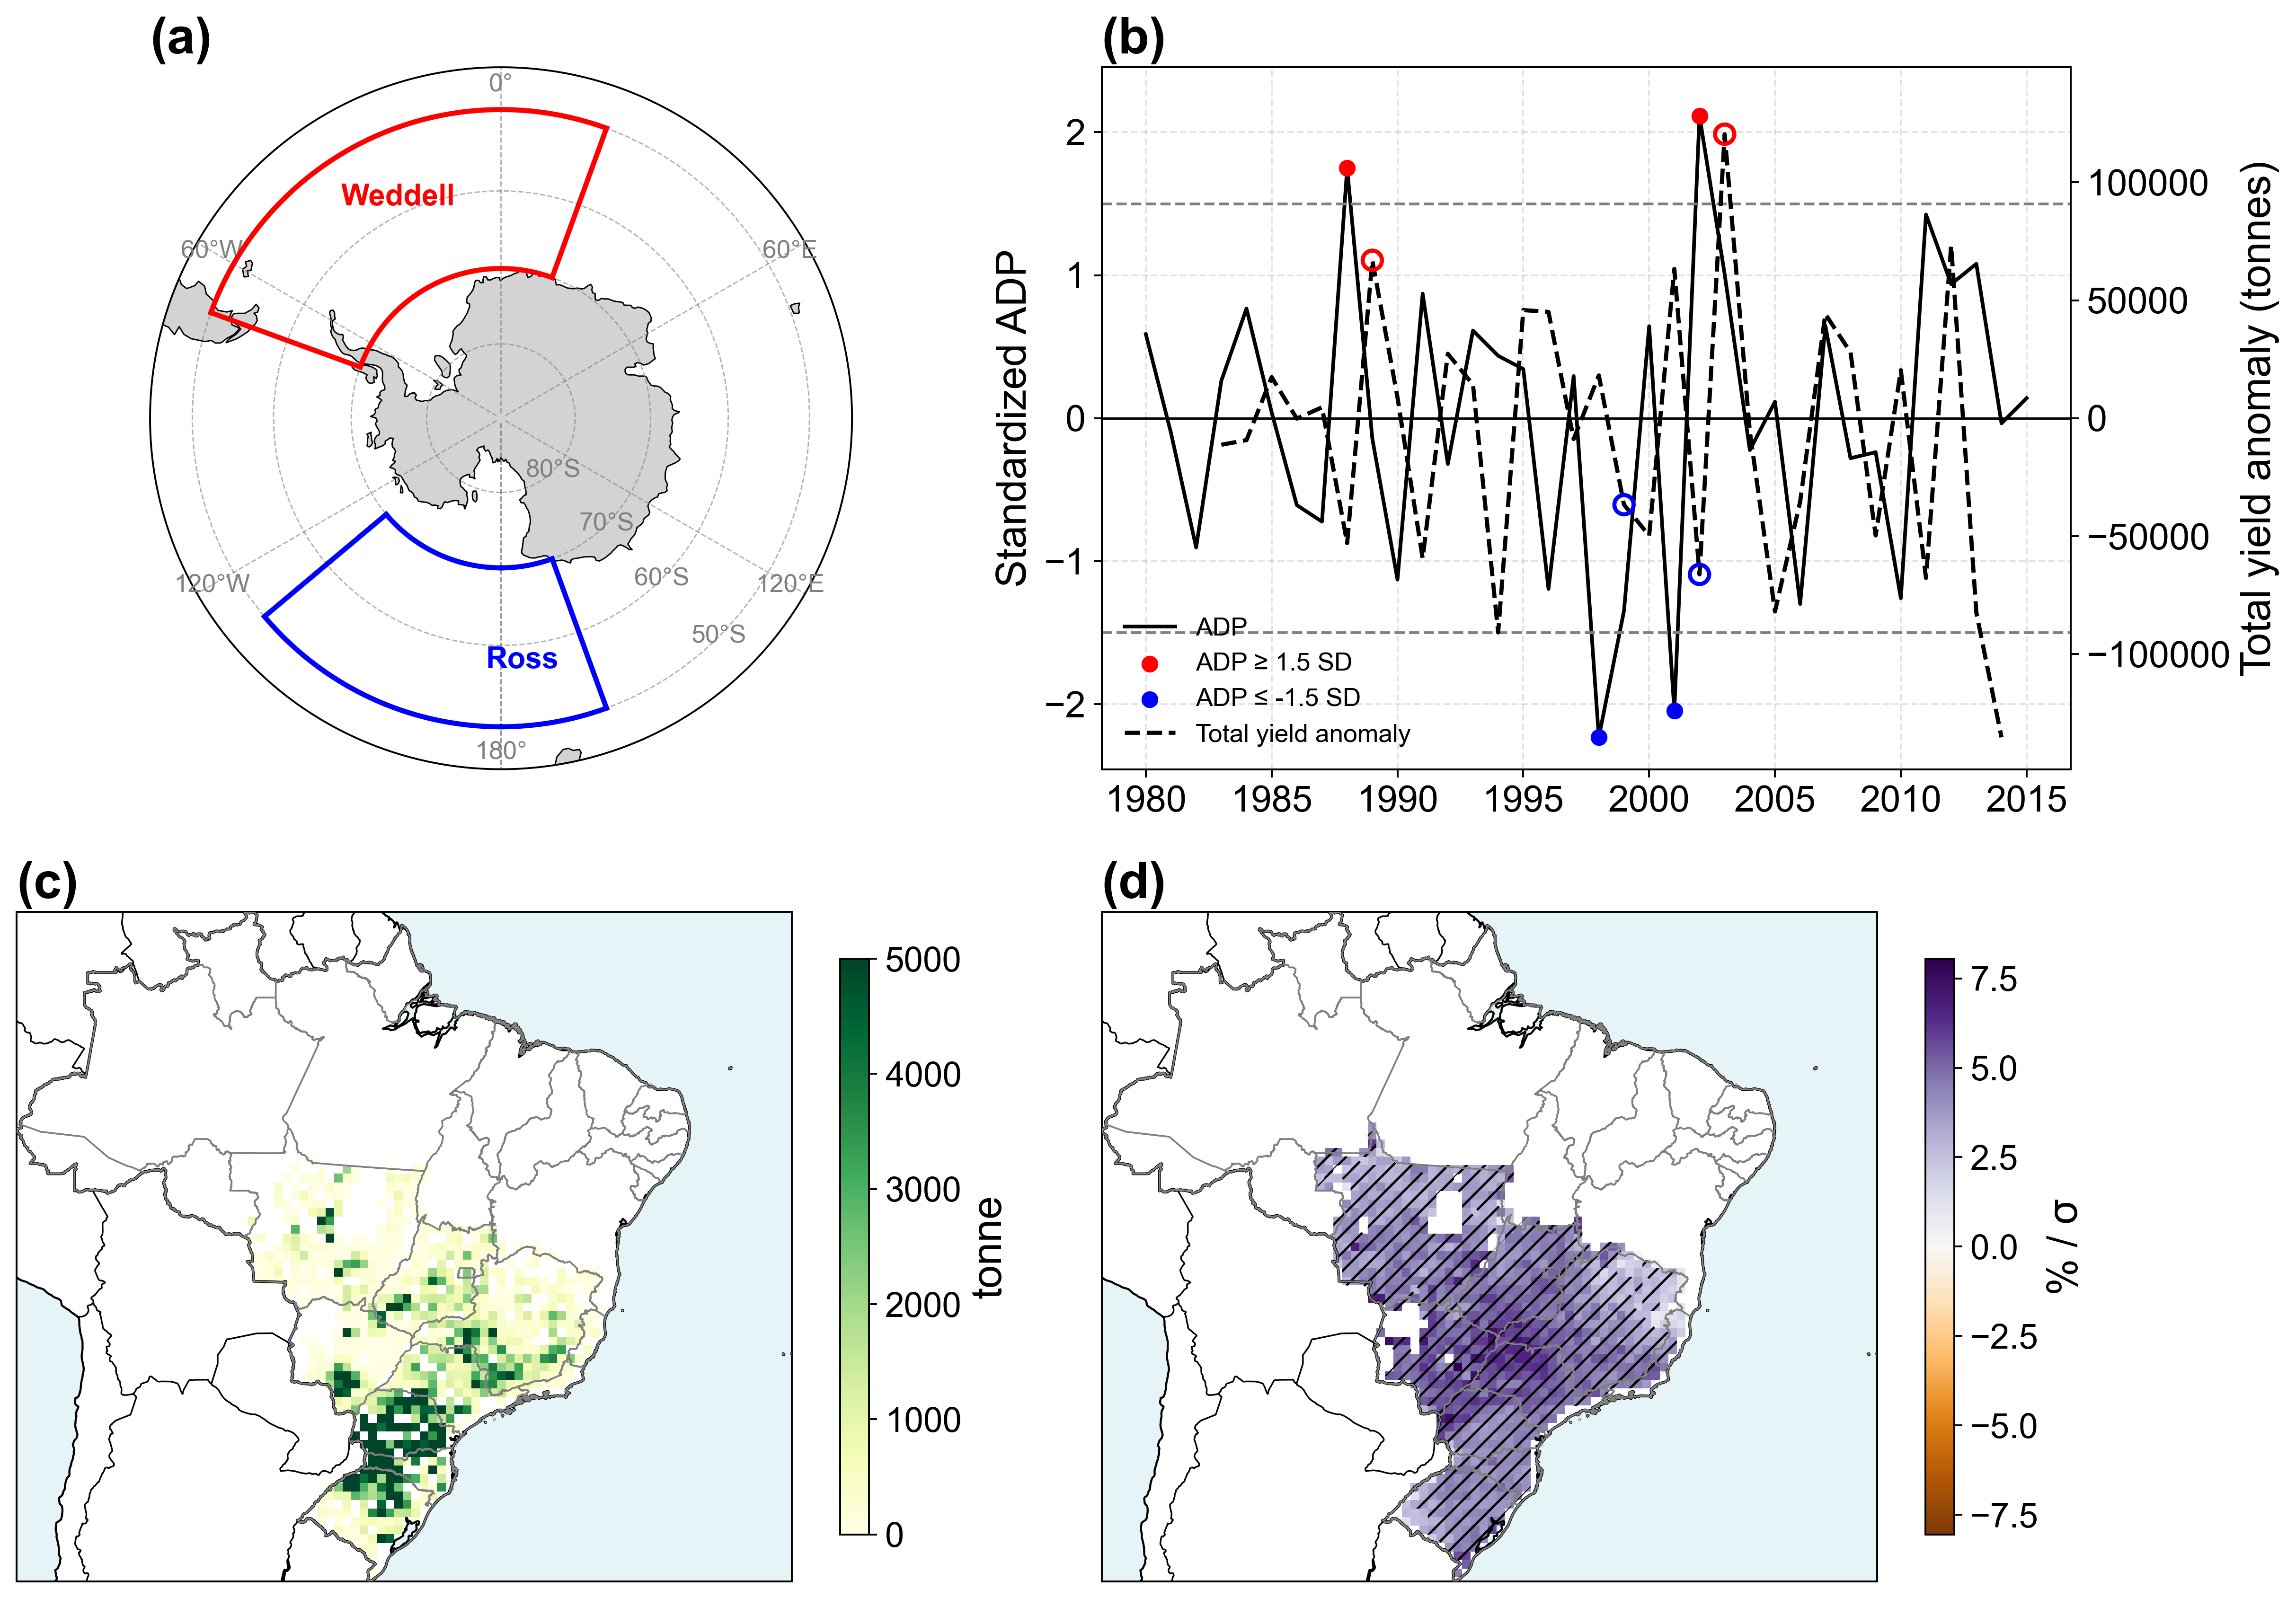

In [141]:
plot_adi_4panels(Antarctic_Dipole_OND_1_average['Antarctic_Dipole_OND_1_average'],
    total_yield_Brazil_sum_anomaly,
    total_yield_mean,
    reg_pct_per_std=reg_maize_ano_Antarctic_Dipole_BRA['slope'],
    pval=reg_maize_ano_Antarctic_Dipole_BRA['pv'],
    BRA_shp=BRA_shp,
    Brazil=Brazil,)